# WALMART LMI ANALYSIS
### Healthcare + Manufacturing + Semiconductors
### Short-term and Long-term Industry/Occupation Projections

In [3]:
# ============================================================
# WALMART LMI ANALYSIS
# Healthcare + Manufacturing + Semiconductors
# Short-term and Long-term Industry/Occupation Projections
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import re


# ============================================================
# 1. FILE PATHS
# ============================================================

BASE = Path(r"C:\Users\301533\Documents\Walmart")

FILES = {
    "occ_short": BASE / "occ_short_term (6).xlsx",
    "ind_short": BASE / "stip-04-2025to2027 (2).xlsx",
    "ces": BASE / "ces-nsa-04st-2020to2029 (9).xlsx",
    "ind_long": BASE / "ltip-04-2024to2034 (1).xlsx",
    "occ_long": BASE / "ltop-04-2024to2034 (7).xlsx",

    "healthcare": Path(
        r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Requests\OneTimeRequests\2026"
        r"\Walmart LMI Grant Analysis\Walmart industry with occupations Healthcare 09.2026.xlsx"
    ),

    "manufacturing": Path(
        r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Requests\OneTimeRequests\2026"
        r"\Walmart LMI Grant Analysis\Walmart industry with occupations Manufacturing 09.2026.xlsx"
    ),

    "semiconductors": Path(
        r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Requests\OneTimeRequests\2026"
        r"\Walmart LMI Grant Analysis\Walmart Matched Occupations (semiconductors- aca definition).xlsx"
    )
}

OUTPUT_FOLDER = BASE / "Walmart_LMI_Output"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_FOLDER / "Walmart_LMI_Analysis.xlsx"


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def clean_column_names(df):
    """Clean Excel column names."""
    df = df.copy()

    df.columns = [
        re.sub(r"\s+", " ", str(c))
        .strip()
        .replace("\n", " ")
        for c in df.columns
    ]

    return df


def clean_code(x):
    """
    Standardize SOC / NAICS codes while preserving hyphens.
    Removes Excel .0 endings.
    """
    if pd.isna(x):
        return np.nan

    x = str(x).strip()
    x = re.sub(r"\.0$", "", x)

    return x


def find_column(df, possible_names):
    """
    Finds a column using exact or partial matching.
    """
    cols = list(df.columns)

    # Exact match first
    for possible in possible_names:
        for col in cols:
            if col.lower().strip() == possible.lower().strip():
                return col

    # Partial match second
    for possible in possible_names:
        for col in cols:
            if possible.lower() in col.lower():
                return col

    return None


def read_best_sheet(path):
    """
    Reads the sheet with the most usable rows/columns.
    Helps avoid title/notes tabs.
    """
    xl = pd.ExcelFile(path)

    best_df = None
    best_sheet = None
    best_score = -1

    for sheet in xl.sheet_names:

        try:
            temp = pd.read_excel(path, sheet_name=sheet)

            temp = clean_column_names(temp)

            temp = temp.dropna(how="all")
            temp = temp.dropna(axis=1, how="all")

            score = temp.shape[0] * temp.shape[1]

            if score > best_score:
                best_score = score
                best_df = temp
                best_sheet = sheet

        except:
            continue

    print(f"{path.name}: using sheet '{best_sheet}'")

    return best_df


def standardize_soc(df):
    """Create standard SOC column when one exists."""

    df = df.copy()

    soc_col = find_column(
        df,
        [
            "SOC",
            "SOC Code",
            "SOC_CODE",
            "Occupation Code",
            "OCC_CODE",
            "Standard Occupational Classification"
        ]
    )

    if soc_col:
        df["SOC"] = df[soc_col].apply(clean_code)

    return df


def standardize_naics(df):
    """Create standard NAICS column when one exists."""

    df = df.copy()

    naics_col = find_column(
        df,
        [
            "NAICS",
            "NAICS Code",
            "NAICS_CODE",
            "Industry Code"
        ]
    )

    if naics_col:
        df["NAICS"] = df[naics_col].apply(clean_code)

    return df


def standardize_occ_title(df):
    """Create standard Occupation column."""

    df = df.copy()

    title_col = find_column(
        df,
        [
            "Occupation Title",
            "Occupation",
            "OCC_TITLE",
            "SOC Title"
        ]
    )

    if title_col:
        df["Occupation"] = df[title_col]

    return df


def standardize_industry_title(df):
    """Create standard Industry column."""

    df = df.copy()

    title_col = find_column(
        df,
        [
            "Industry Title",
            "Industry",
            "NAICS Title"
        ]
    )

    if title_col:
        df["Industry"] = df[title_col]

    return df


# ============================================================
# 3. LOAD ALL FILES
# ============================================================

occ_short = read_best_sheet(FILES["occ_short"])
ind_short = read_best_sheet(FILES["ind_short"])
ces = read_best_sheet(FILES["ces"])
ind_long = read_best_sheet(FILES["ind_long"])
occ_long = read_best_sheet(FILES["occ_long"])

healthcare = read_best_sheet(FILES["healthcare"])
manufacturing = read_best_sheet(FILES["manufacturing"])
semiconductors = read_best_sheet(FILES["semiconductors"])


# ============================================================
# 4. STANDARDIZE CODES/TITLES
# ============================================================

# Occupation projection datasets
occ_short = standardize_soc(occ_short)
occ_short = standardize_occ_title(occ_short)

occ_long = standardize_soc(occ_long)
occ_long = standardize_occ_title(occ_long)

# Industry projection datasets
ind_short = standardize_naics(ind_short)
ind_short = standardize_industry_title(ind_short)

ind_long = standardize_naics(ind_long)
ind_long = standardize_industry_title(ind_long)

ces = standardize_naics(ces)
ces = standardize_industry_title(ces)

# Sector staffing pattern files
for df in [healthcare, manufacturing, semiconductors]:
    pass

healthcare = standardize_soc(healthcare)
healthcare = standardize_naics(healthcare)
healthcare = standardize_occ_title(healthcare)
healthcare = standardize_industry_title(healthcare)

manufacturing = standardize_soc(manufacturing)
manufacturing = standardize_naics(manufacturing)
manufacturing = standardize_occ_title(manufacturing)
manufacturing = standardize_industry_title(manufacturing)

semiconductors = standardize_soc(semiconductors)
semiconductors = standardize_naics(semiconductors)
semiconductors = standardize_occ_title(semiconductors)
semiconductors = standardize_industry_title(semiconductors)


# ============================================================
# 5. ADD SECTOR LABELS
# ============================================================

healthcare["Sector"] = "Healthcare"
manufacturing["Sector"] = "Manufacturing"
semiconductors["Sector"] = "Semiconductors"


# ============================================================
# 6. COMBINE SECTOR OCCUPATION LISTS
# ============================================================

sector_occ = pd.concat(
    [
        healthcare,
        manufacturing,
        semiconductors
    ],
    ignore_index=True,
    sort=False
)


# Keep only records with SOC codes
if "SOC" in sector_occ.columns:
    sector_occ = sector_occ[
        sector_occ["SOC"].notna()
    ].copy()


# ============================================================
# 7. CREATE UNIQUE SECTOR × OCCUPATION TABLE
# ============================================================

keep_cols = [
    c for c in [
        "Sector",
        "SOC",
        "Occupation",
        "NAICS",
        "Industry"
    ]
    if c in sector_occ.columns
]

sector_occ_unique = (
    sector_occ[keep_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)


# ============================================================
# 8. PREP SHORT-TERM OCCUPATION PROJECTIONS
# ============================================================

short_soc = occ_short.copy()

# Remove duplicate SOC/title columns before merge
short_drop = [
    c for c in ["Occupation"]
    if c in short_soc.columns
]

# Rename projection variables so it is obvious which file they came from
short_rename = {}

for col in short_soc.columns:

    if col not in ["SOC", "Occupation"]:
        short_rename[col] = f"ST_{col}"

short_soc = short_soc.rename(columns=short_rename)


# ============================================================
# 9. PREP LONG-TERM OCCUPATION PROJECTIONS
# ============================================================

long_soc = occ_long.copy()

long_rename = {}

for col in long_soc.columns:

    if col not in ["SOC", "Occupation"]:
        long_rename[col] = f"LT_{col}"

long_soc = long_soc.rename(columns=long_rename)


# ============================================================
# 10. MERGE OCCUPATION PROJECTIONS INTO SECTOR OCCUPATIONS
# ============================================================

occupation_analysis = sector_occ_unique.copy()

if "SOC" in short_soc.columns:

    occupation_analysis = occupation_analysis.merge(
        short_soc,
        on="SOC",
        how="left",
        suffixes=("", "_ST")
    )

if "SOC" in long_soc.columns:

    occupation_analysis = occupation_analysis.merge(
        long_soc,
        on="SOC",
        how="left",
        suffixes=("", "_LT")
    )


# ============================================================
# 11. IDENTIFY USEFUL PROJECTION VARIABLES
# ============================================================

def first_matching_column(df, words):

    for col in df.columns:

        name = col.lower()

        if all(word.lower() in name for word in words):
            return col

    return None


# Long-term employment columns
lt_base = first_matching_column(
    occupation_analysis,
    ["LT_", "2024"]
)

lt_projected = first_matching_column(
    occupation_analysis,
    ["LT_", "2034"]
)

# Short-term columns
st_base = first_matching_column(
    occupation_analysis,
    ["ST_", "2025"]
)

st_projected = first_matching_column(
    occupation_analysis,
    ["ST_", "2027"]
)


# ============================================================
# 12. CALCULATE GROWTH WHEN POSSIBLE
# ============================================================

if lt_base and lt_projected:

    occupation_analysis["LT_Employment_Change"] = (
        pd.to_numeric(
            occupation_analysis[lt_projected],
            errors="coerce"
        )
        -
        pd.to_numeric(
            occupation_analysis[lt_base],
            errors="coerce"
        )
    )

    occupation_analysis["LT_Percent_Change"] = (
        occupation_analysis["LT_Employment_Change"]
        /
        pd.to_numeric(
            occupation_analysis[lt_base],
            errors="coerce"
        )
        * 100
    )


if st_base and st_projected:

    occupation_analysis["ST_Employment_Change"] = (
        pd.to_numeric(
            occupation_analysis[st_projected],
            errors="coerce"
        )
        -
        pd.to_numeric(
            occupation_analysis[st_base],
            errors="coerce"
        )
    )

    occupation_analysis["ST_Percent_Change"] = (
        occupation_analysis["ST_Employment_Change"]
        /
        pd.to_numeric(
            occupation_analysis[st_base],
            errors="coerce"
        )
        * 100
    )


# ============================================================
# 13. INDUSTRY LIST FROM SECTOR FILES
# ============================================================

# Check which sector files actually contain NAICS
industry_frames = []

for sector_name, df in {
    "Healthcare": healthcare,
    "Manufacturing": manufacturing,
    "Semiconductors": semiconductors
}.items():

    if "NAICS" in df.columns:

        temp = df.copy()
        temp["Sector"] = sector_name

        keep = ["Sector", "NAICS"]

        if "Industry" in temp.columns:
            keep.append("Industry")

        temp = temp[keep]

        temp = temp[
            temp["NAICS"].notna()
        ]

        industry_frames.append(temp)

        print(
            f"{sector_name}: "
            f"{temp['NAICS'].nunique()} unique NAICS codes"
        )

    else:

        print(
            f"{sector_name}: no NAICS column found — "
            "skipping for industry analysis"
        )


# Combine only files that actually had NAICS
if industry_frames:

    sector_industries = (
        pd.concat(
            industry_frames,
            ignore_index=True
        )
        .drop_duplicates()
        .reset_index(drop=True)
    )

else:

    sector_industries = pd.DataFrame(
        columns=["Sector", "NAICS", "Industry"]
    )


print("\nIndustry records created:")
print(sector_industries.shape)

display(sector_industries.head())


# ============================================================
# 14. PREP SHORT-TERM INDUSTRY PROJECTIONS
# ============================================================

short_ind = ind_short.copy()

short_ind_rename = {}

for col in short_ind.columns:

    if col not in ["NAICS", "Industry"]:
        short_ind_rename[col] = f"ST_{col}"

short_ind = short_ind.rename(columns=short_ind_rename)


# ============================================================
# 15. PREP LONG-TERM INDUSTRY PROJECTIONS
# ============================================================

long_ind = ind_long.copy()

long_ind_rename = {}

for col in long_ind.columns:

    if col not in ["NAICS", "Industry"]:
        long_ind_rename[col] = f"LT_{col}"

long_ind = long_ind.rename(columns=long_ind_rename)


# ============================================================
# 16. PREP CES DATA
# ============================================================

ces_analysis = ces.copy()

ces_rename = {}

for col in ces_analysis.columns:

    if col not in ["NAICS", "Industry"]:
        ces_rename[col] = f"CES_{col}"

ces_analysis = ces_analysis.rename(columns=ces_rename)


# ============================================================
# 17. MERGE INDUSTRY DATA
# ============================================================

industry_analysis = sector_industries.copy()

if "NAICS" in short_ind.columns:

    industry_analysis = industry_analysis.merge(
        short_ind,
        on="NAICS",
        how="left",
        suffixes=("", "_ST")
    )

if "NAICS" in long_ind.columns:

    industry_analysis = industry_analysis.merge(
        long_ind,
        on="NAICS",
        how="left",
        suffixes=("", "_LT")
    )

if "NAICS" in ces_analysis.columns:

    industry_analysis = industry_analysis.merge(
        ces_analysis,
        on="NAICS",
        how="left",
        suffixes=("", "_CES")
    )


# ============================================================
# 18. SECTOR SUMMARY
# ============================================================

summary_dict = {}

# Count unique occupations
if "SOC" in occupation_analysis.columns:
    summary_dict["Unique_Occupations"] = ("SOC", "nunique")

elif "Occupation" in occupation_analysis.columns:
    summary_dict["Unique_Occupations"] = ("Occupation", "nunique")


# Count unique industries if available
if "NAICS" in occupation_analysis.columns:
    summary_dict["Unique_Industries"] = ("NAICS", "nunique")

elif "Industry" in occupation_analysis.columns:
    summary_dict["Unique_Industries"] = ("Industry", "nunique")


# Add long-term employment change
if "LT_Employment_Change" in occupation_analysis.columns:
    summary_dict["LT_Employment_Change"] = (
        "LT_Employment_Change",
        "sum"
    )


# Add short-term employment change
if "ST_Employment_Change" in occupation_analysis.columns:
    summary_dict["ST_Employment_Change"] = (
        "ST_Employment_Change",
        "sum"
    )


# Create summary
if summary_dict:

    sector_summary = (
        occupation_analysis
        .groupby("Sector", as_index=False)
        .agg(**summary_dict)
    )

else:

    sector_summary = (
        occupation_analysis[["Sector"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )


print("\nSector Summary:")
display(sector_summary)

# ============================================================
# 19. TOP GROWING OCCUPATIONS
# ============================================================

if "LT_Employment_Change" in occupation_analysis.columns:

    top_growing_occ = (
        occupation_analysis
        .sort_values(
            ["Sector", "LT_Employment_Change"],
            ascending=[True, False]
        )
        .groupby("Sector")
        .head(25)
        .reset_index(drop=True)
    )

else:

    top_growing_occ = occupation_analysis.copy()


# ============================================================
# 20. DECLINING OCCUPATIONS
# ============================================================

if "LT_Employment_Change" in occupation_analysis.columns:

    declining_occ = (
        occupation_analysis[
            occupation_analysis["LT_Employment_Change"] < 0
        ]
        .sort_values(
            ["Sector", "LT_Employment_Change"]
        )
        .reset_index(drop=True)
    )

else:

    declining_occ = pd.DataFrame()


# ============================================================
# 21. OCCUPATION CROSS-SECTOR OVERLAP
# ============================================================

occupation_overlap = (
    sector_occ_unique
    .groupby(
        ["SOC", "Occupation"],
        dropna=False
    )
    .agg(
        Number_of_Sectors=("Sector", "nunique"),
        Sectors=(
            "Sector",
            lambda x: ", ".join(
                sorted(set(x.dropna()))
            )
        )
    )
    .reset_index()
    .sort_values(
        ["Number_of_Sectors", "Occupation"],
        ascending=[False, True]
    )
)


# ============================================================
# 22. CREATE DATA QUALITY / MATCH CHECK
# ============================================================

match_check = []

for sector in occupation_analysis["Sector"].dropna().unique():

    temp = occupation_analysis[
        occupation_analysis["Sector"] == sector
    ]

    total = temp["SOC"].nunique()

    short_matches = np.nan
    long_matches = np.nan

    if any(c.startswith("ST_") for c in temp.columns):

        st_cols = [
            c for c in temp.columns
            if c.startswith("ST_")
        ]

        short_matches = (
            temp[st_cols]
            .notna()
            .any(axis=1)
            .sum()
        )

    if any(c.startswith("LT_") for c in temp.columns):

        lt_cols = [
            c for c in temp.columns
            if c.startswith("LT_")
        ]

        long_matches = (
            temp[lt_cols]
            .notna()
            .any(axis=1)
            .sum()
        )

    match_check.append({
        "Sector": sector,
        "Unique_SOCs": total,
        "Matched_Short_Term": short_matches,
        "Matched_Long_Term": long_matches
    })


match_check = pd.DataFrame(match_check)


# ============================================================
# 23. SORT MAIN OUTPUT
# ============================================================

sort_cols = [
    c for c in [
        "Sector",
        "LT_Employment_Change",
        "Occupation"
    ]
    if c in occupation_analysis.columns
]

ascending = [
    False if c == "LT_Employment_Change" else True
    for c in sort_cols
]

if sort_cols:

    occupation_analysis = occupation_analysis.sort_values(
        sort_cols,
        ascending=ascending
    )


# ============================================================
# 24. EXPORT EVERYTHING TO ONE EXCEL WORKBOOK
# ============================================================

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    # Main tables
    sector_summary.to_excel(
        writer,
        sheet_name="Sector Summary",
        index=False
    )

    occupation_analysis.to_excel(
        writer,
        sheet_name="Occupation Analysis",
        index=False
    )

    industry_analysis.to_excel(
        writer,
        sheet_name="Industry Analysis",
        index=False
    )

    top_growing_occ.to_excel(
        writer,
        sheet_name="Top Growing Occupations",
        index=False
    )

    declining_occ.to_excel(
        writer,
        sheet_name="Declining Occupations",
        index=False
    )

    occupation_overlap.to_excel(
        writer,
        sheet_name="Occupation Overlap",
        index=False
    )

    match_check.to_excel(
        writer,
        sheet_name="Match Check",
        index=False
    )

    # Original sector lists
    healthcare.to_excel(
        writer,
        sheet_name="Healthcare Source",
        index=False
    )

    manufacturing.to_excel(
        writer,
        sheet_name="Manufacturing Source",
        index=False
    )

    semiconductors.to_excel(
        writer,
        sheet_name="Semiconductor Source",
        index=False
    )

    # Projection source datasets
    occ_short.to_excel(
        writer,
        sheet_name="Short Term Occup Proj",
        index=False
    )

    occ_long.to_excel(
        writer,
        sheet_name="Long Term Occup Proj",
        index=False
    )

    ind_short.to_excel(
        writer,
        sheet_name="Short Term Ind Proj",
        index=False
    )

    ind_long.to_excel(
        writer,
        sheet_name="Long Term Ind Proj",
        index=False
    )


# ============================================================
# 25. SAVE CSV VERSIONS OF THE MOST USEFUL TABLES
# ============================================================

occupation_analysis.to_csv(
    OUTPUT_FOLDER / "Occupation_Analysis.csv",
    index=False
)

industry_analysis.to_csv(
    OUTPUT_FOLDER / "Industry_Analysis.csv",
    index=False
)

sector_summary.to_csv(
    OUTPUT_FOLDER / "Sector_Summary.csv",
    index=False
)

occupation_overlap.to_csv(
    OUTPUT_FOLDER / "Occupation_Overlap.csv",
    index=False
)


# ============================================================
# 26. FINAL CHECK
# ============================================================

print("\n======================================")
print("WALMART LMI ANALYSIS COMPLETE")
print("======================================")

print(f"\nOutput folder:\n{OUTPUT_FOLDER}")

print(f"\nMain workbook:\n{OUTPUT_FILE}")

print("\nSector occupation counts:")
print(
    sector_occ_unique
    .groupby("Sector")["SOC"]
    .nunique()
)

print("\nProjection match check:")
print(match_check)

print("\nFiles created successfully.")

occ_short_term (6).xlsx: using sheet 'OCC_Proj_ALL_25_27'
stip-04-2025to2027 (2).xlsx: using sheet '2025-27 AZ Industry Projections'
ces-nsa-04st-2020to2029 (9).xlsx: using sheet '2026'
ltip-04-2024to2034 (1).xlsx: using sheet '2024-34 Industry Projections'
ltop-04-2024to2034 (7).xlsx: using sheet 'Occupation_Projections_24_34'
Walmart industry with occupations Healthcare 09.2026.xlsx: using sheet 'Maricopa County 2-digit'
Walmart industry with occupations Manufacturing 09.2026.xlsx: using sheet 'Maricopa County 2-digit'
Walmart Matched Occupations (semiconductors- aca definition).xlsx: using sheet 'Sheet2'
Healthcare: no NAICS column found — skipping for industry analysis
Manufacturing: no NAICS column found — skipping for industry analysis
Semiconductors: no NAICS column found — skipping for industry analysis

Industry records created:
(0, 3)


c:\Users\301533\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Sector,NAICS,Industry



Sector Summary:


,Sector,Unique_Occupations
0,Healthcare,0
1,Manufacturing,5
2,Semiconductors,5


KeyError: 'SOC'

In [9]:
# ============================================================
# CHECK AVAILABLE PROJECTION COLUMNS
# ============================================================

print("SHORT-TERM PROJECTION COLUMNS")
for col in occ_short_detail.columns:
    print(col)

print("\nLONG-TERM PROJECTION COLUMNS")
for col in occ_long_detail.columns:
    print(col)

SHORT-TERM PROJECTION COLUMNS
Area
SOC
Occupation
ST_2025_Employment
ST_2027_Employment
ST_Numeric_Change
ST_Percent_Change
ST_Growth_Openings
ST_Transfer_Openings
ST_Exit_Openings
ST_Total_Openings
Valid_SOC

LONG-TERM PROJECTION COLUMNS
Area
SOC
Occupation
LT_2024_Employment
LT_2034_Employment
LT_Numeric_Change
LT_Percent_Change
LT_Annualized_Percent_Change
LT_Exit_Openings
LT_Transfer_Openings
LT_Growth_Openings
LT_Total_Openings
Valid_SOC


In [15]:
# ============================================================
# FINAL OCCUPATION OUTLOOK TABLE
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. PREPARE HEALTHCARE
# ============================================================

healthcare_simple = healthcare_detail[
    ["SOC", "Occupation", "Average Wage ('25)"]
].copy()

healthcare_simple = healthcare_simple.rename(columns={
    "Average Wage ('25)": "Average_Wage"
})

healthcare_simple["Sector"] = "Healthcare"


# ============================================================
# 2. PREPARE MANUFACTURING
# ============================================================

manufacturing_simple = manufacturing_detail[
    ["SOC", "Occupation", "Average Wage ('25)"]
].copy()

manufacturing_simple = manufacturing_simple.rename(columns={
    "Average Wage ('25)": "Average_Wage"
})

manufacturing_simple["Sector"] = "Manufacturing"


# ============================================================
# 3. PREPARE SEMICONDUCTORS
# ============================================================

semiconductors_simple = semiconductors_detail[
    ["SOC", "Occupation", "Median Hourly Earnings"]
].copy()

semiconductors_simple["Sector"] = "Semiconductors"

semiconductors_simple["Median Hourly Earnings"] = (
    semiconductors_simple["Median Hourly Earnings"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

semiconductors_simple["Median Hourly Earnings"] = pd.to_numeric(
    semiconductors_simple["Median Hourly Earnings"],
    errors="coerce"
)

# Convert hourly earnings to annual earnings
semiconductors_simple["Average_Wage"] = (
    semiconductors_simple["Median Hourly Earnings"] * 2080
)


# ============================================================
# 4. COMBINE SECTOR OCCUPATION LISTS
# ============================================================

sector_occupations = pd.concat(
    [
        healthcare_simple[
            ["Sector", "SOC", "Occupation", "Average_Wage"]
        ],
        manufacturing_simple[
            ["Sector", "SOC", "Occupation", "Average_Wage"]
        ],
        semiconductors_simple[
            ["Sector", "SOC", "Occupation", "Average_Wage"]
        ]
    ],
    ignore_index=True
)


# Clean SOC codes
sector_occupations["SOC"] = (
    sector_occupations["SOC"]
    .astype(str)
    .str.strip()
)


# Clean annual wage values
sector_occupations["Average_Wage"] = (
    sector_occupations["Average_Wage"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

sector_occupations["Average_Wage"] = pd.to_numeric(
    sector_occupations["Average_Wage"],
    errors="coerce"
)


# Keep one record per sector and occupation
sector_occupations = sector_occupations.drop_duplicates(
    subset=["Sector", "SOC"]
)


# ============================================================
# 5. PREPARE OFFICIAL LONG-TERM ARIZONA PROJECTIONS
# ============================================================

long_term_simple = occ_long_detail[
    [
        "SOC",
        "Occupation",
        "LT_2024_Employment",
        "LT_2034_Employment",
        "LT_Numeric_Change",
        "LT_Percent_Change"
    ]
].copy()


long_term_simple = long_term_simple.rename(columns={
    "Occupation": "Projection_Occupation",
    "LT_2024_Employment": "Current_Employment",
    "LT_2034_Employment": "Projected_Employment_10yr",
    "LT_Numeric_Change": "Job_Change_10yr",
    "LT_Percent_Change": "Growth_Rate_10yr"
})


long_term_simple["SOC"] = (
    long_term_simple["SOC"]
    .astype(str)
    .str.strip()
)


numeric_projection_columns = [
    "Current_Employment",
    "Projected_Employment_10yr",
    "Job_Change_10yr",
    "Growth_Rate_10yr"
]

for col in numeric_projection_columns:

    long_term_simple[col] = pd.to_numeric(
        long_term_simple[col],
        errors="coerce"
    )


# ============================================================
# 6. MERGE SECTOR OCCUPATIONS WITH PROJECTIONS
# ============================================================

occupation_outlook = sector_occupations.merge(
    long_term_simple,
    on="SOC",
    how="left",
    validate="many_to_one"
)


# Prefer the official projection occupation title
occupation_outlook["Occupation_Title"] = (
    occupation_outlook["Projection_Occupation"]
    .fillna(occupation_outlook["Occupation"])
)


# ============================================================
# 7. CREATE FINAL TABLE
# ============================================================

occupation_outlook_final = occupation_outlook[
    [
        "Sector",
        "SOC",
        "Occupation_Title",
        "Current_Employment",
        "Average_Wage",
        "Projected_Employment_10yr",
        "Job_Change_10yr",
        "Growth_Rate_10yr"
    ]
].copy()


occupation_outlook_final = occupation_outlook_final.rename(columns={
    "Occupation_Title": "Occupation"
})


occupation_outlook_final = occupation_outlook_final.sort_values(
    ["Sector", "Projected_Employment_10yr"],
    ascending=[True, False]
).reset_index(drop=True)


# ============================================================
# 8. QUALITY CHECK
# ============================================================

print("=" * 70)
print("FINAL OCCUPATION OUTLOOK")
print("=" * 70)

print("\nRows by sector:")
print(
    occupation_outlook_final
    .groupby("Sector")
    .size()
)

print("\nMissing values:")
print(
    occupation_outlook_final[
        [
            "Current_Employment",
            "Average_Wage",
            "Projected_Employment_10yr",
            "Job_Change_10yr",
            "Growth_Rate_10yr"
        ]
    ].isna().sum()
)


display(occupation_outlook_final.head(20))

FINAL OCCUPATION OUTLOOK

Rows by sector:
Sector
Healthcare        51
Manufacturing     70
Semiconductors    21
dtype: int64

Missing values:
Current_Employment           0
Average_Wage                 0
Projected_Employment_10yr    0
Job_Change_10yr              0
Growth_Rate_10yr             0
dtype: int64


,Sector,SOC,Occupation,Current_Employment,Average_Wage,Projected_Employment_10yr,Job_Change_10yr,Growth_Rate_10yr
0,Healthcare,29-1141,Registered Nurses,68467.0,99730.0,81224.0,12757.0,0.1863
1,Healthcare,43-9061,"Office Clerks, General",54428.0,49100.0,55062.0,634.0,0.0116
2,Healthcare,43-6013,Medical Secretaries and Administrative Assistants,17449.0,46330.0,20146.0,2697.0,0.1546
3,Healthcare,29-1171,Nurse Practitioners,7827.0,140600.0,12083.0,4256.0,0.5438
4,Healthcare,43-3021,Billing and Posting Clerks,10627.0,48850.0,11783.0,1156.0,0.1088
5,Healthcare,31-9091,Dental Assistants,7609.0,50280.0,8804.0,1195.0,0.1571
6,Healthcare,35-2012,"Cooks, Institution and Cafeteria",7185.0,41350.0,8418.0,1233.0,0.1716
7,Healthcare,29-1123,Physical Therapists,5089.0,107360.0,6314.0,1225.0,0.2407
8,Healthcare,29-2061,Licensed Practical and Licensed Vocational Nurses,5430.0,76120.0,6294.0,864.0,0.1591
9,Healthcare,29-1292,Dental Hygienists,5154.0,101450.0,5990.0,836.0,0.1622


In [16]:
# ============================================================
# FORMAT AND EXPORT FINAL OCCUPATION OUTLOOK
# ============================================================

occupation_outlook_export = occupation_outlook_final.copy()


# Rename columns for presentation
occupation_outlook_export = occupation_outlook_export.rename(columns={
    "Current_Employment": "2024 Employment",
    "Average_Wage": "Average Annual Wage",
    "Projected_Employment_10yr": "2034 Projected Employment",
    "Job_Change_10yr": "2024–2034 Job Change",
    "Growth_Rate_10yr": "2024–2034 Growth Rate"
})


# Create formatted display version
occupation_outlook_display = occupation_outlook_export.copy()

employment_columns = [
    "2024 Employment",
    "2034 Projected Employment",
    "2024–2034 Job Change"
]

for col in employment_columns:
    occupation_outlook_display[col] = (
        occupation_outlook_display[col]
        .apply(lambda x: f"{x:,.0f}")
    )


occupation_outlook_display["Average Annual Wage"] = (
    occupation_outlook_display["Average Annual Wage"]
    .apply(lambda x: f"${x:,.0f}")
)


occupation_outlook_display["2024–2034 Growth Rate"] = (
    occupation_outlook_display["2024–2034 Growth Rate"]
    .apply(lambda x: f"{x:.1%}")
)


display(occupation_outlook_display.head(20))

,Sector,SOC,Occupation,2024 Employment,Average Annual Wage,2034 Projected Employment,2024–2034 Job Change,2024–2034 Growth Rate
0,Healthcare,29-1141,Registered Nurses,"68,467","$99,730","81,224","12,757",18.6%
1,Healthcare,43-9061,"Office Clerks, General","54,428","$49,100","55,062",634,1.2%
2,Healthcare,43-6013,Medical Secretaries and Administrative Assistants,"17,449","$46,330","20,146","2,697",15.5%
3,Healthcare,29-1171,Nurse Practitioners,"7,827","$140,600","12,083","4,256",54.4%
4,Healthcare,43-3021,Billing and Posting Clerks,"10,627","$48,850","11,783","1,156",10.9%
5,Healthcare,31-9091,Dental Assistants,"7,609","$50,280","8,804","1,195",15.7%
6,Healthcare,35-2012,"Cooks, Institution and Cafeteria","7,185","$41,350","8,418","1,233",17.2%
7,Healthcare,29-1123,Physical Therapists,"5,089","$107,360","6,314","1,225",24.1%
8,Healthcare,29-2061,Licensed Practical and Licensed Vocational Nurses,"5,430","$76,120","6,294",864,15.9%
9,Healthcare,29-1292,Dental Hygienists,"5,154","$101,450","5,990",836,16.2%


In [17]:
# ============================================================
# AGGREGATE OCCUPATIONS TO 2-DIGIT SOC GROUPS
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. CREATE 2-DIGIT SOC
# ============================================================

soc_2digit = occupation_outlook_final.copy()

soc_2digit["SOC_2_Digit"] = (
    soc_2digit["SOC"]
    .astype(str)
    .str.extract(r"^(\d{2})", expand=False)
)


# ============================================================
# 2. ADD MAJOR OCCUPATION-GROUP TITLES
# ============================================================

soc_major_titles = {
    "11": "Management Occupations",
    "13": "Business and Financial Operations Occupations",
    "15": "Computer and Mathematical Occupations",
    "17": "Architecture and Engineering Occupations",
    "19": "Life, Physical, and Social Science Occupations",
    "21": "Community and Social Service Occupations",
    "23": "Legal Occupations",
    "25": "Educational Instruction and Library Occupations",
    "27": "Arts, Design, Entertainment, Sports, and Media Occupations",
    "29": "Healthcare Practitioners and Technical Occupations",
    "31": "Healthcare Support Occupations",
    "33": "Protective Service Occupations",
    "35": "Food Preparation and Serving Related Occupations",
    "37": "Building and Grounds Cleaning and Maintenance Occupations",
    "39": "Personal Care and Service Occupations",
    "41": "Sales and Related Occupations",
    "43": "Office and Administrative Support Occupations",
    "45": "Farming, Fishing, and Forestry Occupations",
    "47": "Construction and Extraction Occupations",
    "49": "Installation, Maintenance, and Repair Occupations",
    "51": "Production Occupations",
    "53": "Transportation and Material Moving Occupations"
}

soc_2digit["Occupation_Group"] = (
    soc_2digit["SOC_2_Digit"]
    .map(soc_major_titles)
)


# ============================================================
# 3. CALCULATE EMPLOYMENT-WEIGHTED WAGE
# ============================================================

soc_2digit["Wage_x_Employment"] = (
    soc_2digit["Average_Wage"]
    * soc_2digit["Current_Employment"]
)


# ============================================================
# 4. AGGREGATE WITHIN EACH PRIORITY SECTOR
# ============================================================

soc_2digit_summary = (
    soc_2digit
    .groupby(
        [
            "Sector",
            "SOC_2_Digit",
            "Occupation_Group"
        ],
        as_index=False
    )
    .agg(
        Detailed_Occupations=("SOC", "nunique"),
        Current_Employment=("Current_Employment", "sum"),
        Wage_x_Employment=("Wage_x_Employment", "sum"),
        Projected_Employment_10yr=(
            "Projected_Employment_10yr",
            "sum"
        )
    )
)


# ============================================================
# 5. CALCULATE WEIGHTED WAGE, CHANGE, AND GROWTH
# ============================================================

soc_2digit_summary["Average_Wage"] = np.where(
    soc_2digit_summary["Current_Employment"] > 0,
    (
        soc_2digit_summary["Wage_x_Employment"]
        / soc_2digit_summary["Current_Employment"]
    ),
    np.nan
)


soc_2digit_summary["Job_Change_10yr"] = (
    soc_2digit_summary["Projected_Employment_10yr"]
    - soc_2digit_summary["Current_Employment"]
)


soc_2digit_summary["Growth_Rate_10yr"] = np.where(
    soc_2digit_summary["Current_Employment"] > 0,
    (
        soc_2digit_summary["Job_Change_10yr"]
        / soc_2digit_summary["Current_Employment"]
    ),
    np.nan
)


# ============================================================
# 6. CREATE FINAL 2-DIGIT SOC TABLE
# ============================================================

soc_2digit_final = soc_2digit_summary[
    [
        "Sector",
        "SOC_2_Digit",
        "Occupation_Group",
        "Detailed_Occupations",
        "Current_Employment",
        "Average_Wage",
        "Projected_Employment_10yr",
        "Job_Change_10yr",
        "Growth_Rate_10yr"
    ]
].copy()


soc_2digit_final = soc_2digit_final.sort_values(
    [
        "Sector",
        "Current_Employment"
    ],
    ascending=[True, False]
).reset_index(drop=True)


display(soc_2digit_final)

,Sector,SOC_2_Digit,Occupation_Group,Detailed_Occupations,Current_Employment,Average_Wage,Projected_Employment_10yr,Job_Change_10yr,Growth_Rate_10yr
0,Healthcare,29,Healthcare Practitioners and Technical Occupat...,35,137412.0,112380.730286,166793.0,29381.0,0.213817
1,Healthcare,43,Office and Administrative Support Occupations,3,82504.0,48481.963541,86991.0,4487.0,0.054385
2,Healthcare,31,Healthcare Support Occupations,5,18885.0,51148.674609,22501.0,3616.0,0.191475
3,Healthcare,35,Food Preparation and Serving Related Occupations,2,11229.0,39779.794283,13183.0,1954.0,0.174014
4,Healthcare,21,Community and Social Service Occupations,4,6051.0,66601.072550,7313.0,1262.0,0.208561
5,Healthcare,49,"Installation, Maintenance, and Repair Occupations",1,1502.0,63190.000000,1958.0,456.0,0.303595
6,Healthcare,53,Transportation and Material Moving Occupations,1,1373.0,119320.000000,1546.0,173.0,0.126001
7,Manufacturing,51,Production Occupations,45,73474.0,57098.587664,82698.0,9224.0,0.125541
8,Manufacturing,17,Architecture and Engineering Occupations,15,35687.0,114308.065962,41891.0,6204.0,0.173845
9,Manufacturing,43,Office and Administrative Support Occupations,2,29165.0,52231.610835,30757.0,1592.0,0.054586


In [18]:
# ============================================================
# BROAD PRIORITY-SECTOR WORKFORCE COMPARISON
# ============================================================

import pandas as pd
import numpy as np


sector_summary_source = occupation_outlook_final.copy()


# Wage weighted by current employment
sector_summary_source["Wage_x_Employment"] = (
    sector_summary_source["Average_Wage"]
    * sector_summary_source["Current_Employment"]
)


# Aggregate selected occupations within each sector
sector_summary = (
    sector_summary_source
    .groupby("Sector", as_index=False)
    .agg(
        Occupations_Included=("SOC", "nunique"),
        Current_Employment=("Current_Employment", "sum"),
        Projected_Employment_10yr=(
            "Projected_Employment_10yr",
            "sum"
        ),
        Wage_x_Employment=("Wage_x_Employment", "sum")
    )
)


# Calculate sector-level measures
sector_summary["Job_Change_10yr"] = (
    sector_summary["Projected_Employment_10yr"]
    - sector_summary["Current_Employment"]
)


sector_summary["Growth_Rate_10yr"] = np.where(
    sector_summary["Current_Employment"] > 0,
    (
        sector_summary["Job_Change_10yr"]
        / sector_summary["Current_Employment"]
    ),
    np.nan
)


sector_summary["Average_Wage"] = np.where(
    sector_summary["Current_Employment"] > 0,
    (
        sector_summary["Wage_x_Employment"]
        / sector_summary["Current_Employment"]
    ),
    np.nan
)


# ============================================================
# TRANSPOSE INTO REPORT FORMAT
# ============================================================

sector_order = [
    "Semiconductors",
    "Healthcare",
    "Manufacturing"
]


sector_summary = (
    sector_summary
    .set_index("Sector")
    .reindex(sector_order)
)


sector_comparison = pd.DataFrame({
    "Measure": [
        "Detailed occupations included",
        "2024 employment",
        "2034 projected employment",
        "Projected 10-year job growth",
        "Projected 10-year growth rate",
        "Employment-weighted average wage"
    ],

    "Semiconductors": [
        sector_summary.loc[
            "Semiconductors", "Occupations_Included"
        ],
        sector_summary.loc[
            "Semiconductors", "Current_Employment"
        ],
        sector_summary.loc[
            "Semiconductors", "Projected_Employment_10yr"
        ],
        sector_summary.loc[
            "Semiconductors", "Job_Change_10yr"
        ],
        sector_summary.loc[
            "Semiconductors", "Growth_Rate_10yr"
        ],
        sector_summary.loc[
            "Semiconductors", "Average_Wage"
        ]
    ],

    "Healthcare": [
        sector_summary.loc[
            "Healthcare", "Occupations_Included"
        ],
        sector_summary.loc[
            "Healthcare", "Current_Employment"
        ],
        sector_summary.loc[
            "Healthcare", "Projected_Employment_10yr"
        ],
        sector_summary.loc[
            "Healthcare", "Job_Change_10yr"
        ],
        sector_summary.loc[
            "Healthcare", "Growth_Rate_10yr"
        ],
        sector_summary.loc[
            "Healthcare", "Average_Wage"
        ]
    ],

    "Manufacturing": [
        sector_summary.loc[
            "Manufacturing", "Occupations_Included"
        ],
        sector_summary.loc[
            "Manufacturing", "Current_Employment"
        ],
        sector_summary.loc[
            "Manufacturing", "Projected_Employment_10yr"
        ],
        sector_summary.loc[
            "Manufacturing", "Job_Change_10yr"
        ],
        sector_summary.loc[
            "Manufacturing", "Growth_Rate_10yr"
        ],
        sector_summary.loc[
            "Manufacturing", "Average_Wage"
        ]
    ]
})


# ============================================================
# FORMAT FOR DISPLAY
# ============================================================

sector_comparison_display = sector_comparison.copy()


whole_number_measures = [
    "Detailed occupations included",
    "2024 employment",
    "2034 projected employment",
    "Projected 10-year job growth"
]


for sector in sector_order:

    number_mask = (
        sector_comparison_display["Measure"]
        .isin(whole_number_measures)
    )

    sector_comparison_display.loc[number_mask, sector] = (
        sector_comparison_display.loc[number_mask, sector]
        .apply(lambda x: f"{x:,.0f}")
    )


    growth_mask = (
        sector_comparison_display["Measure"]
        == "Projected 10-year growth rate"
    )

    sector_comparison_display.loc[growth_mask, sector] = (
        sector_comparison_display.loc[growth_mask, sector]
        .apply(lambda x: f"{x:.1%}")
    )


    wage_mask = (
        sector_comparison_display["Measure"]
        == "Employment-weighted average wage"
    )

    sector_comparison_display.loc[wage_mask, sector] = (
        sector_comparison_display.loc[wage_mask, sector]
        .apply(lambda x: f"${x:,.0f}")
    )


display(sector_comparison_display)

C:\Users\301533\AppData\Local\Temp\ipykernel_26248\3056651468.py:177: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['21' '165,254' '181,528' '16,274']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  sector_comparison_display.loc[number_mask, sector] = (
C:\Users\301533\AppData\Local\Temp\ipykernel_26248\3056651468.py:177: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['51' '258,956' '300,285' '41,329']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  sector_comparison_display.loc[number_mask, sector] = (
C:\Users\301533\AppData\Local\Temp\ipykernel_26248\3056651468.py:177: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['70' '149,550' '169,577' '20,027']' 

,Measure,Semiconductors,Healthcare,Manufacturing
0,Detailed occupations included,21,51,70
1,2024 employment,"165,254","258,956","149,550"
2,2034 projected employment,"181,528","300,285","169,577"
3,Projected 10-year job growth,"16,274","41,329","20,027"
4,Projected 10-year growth rate,9.8%,16.0%,13.4%
5,Employment-weighted average wage,"$63,606","$83,091","$71,237"


In [19]:
# ============================================================
# ADD 2025 EMPLOYMENT AND LONG-TERM ANNUAL OPENINGS
# ============================================================

additional_projection_data = (
    occ_short_detail[
        [
            "SOC",
            "ST_2025_Employment"
        ]
    ]
    .merge(
        occ_long_detail[
            [
                "SOC",
                "LT_Total_Openings"
            ]
        ],
        on="SOC",
        how="left",
        validate="one_to_one"
    )
)


occupation_summary_source = occupation_outlook_final.merge(
    additional_projection_data,
    on="SOC",
    how="left",
    validate="many_to_one"
)


# Employment-weighted wage
occupation_summary_source["Wage_x_2025_Employment"] = (
    occupation_summary_source["Average_Wage"]
    * occupation_summary_source["ST_2025_Employment"]
)


# ============================================================
# AGGREGATE BY SECTOR
# ============================================================

sector_summary = (
    occupation_summary_source
    .groupby("Sector", as_index=False)
    .agg(
        Detailed_Occupations_Included=("SOC", "nunique"),

        Employment_2025=(
            "ST_2025_Employment",
            "sum"
        ),

        Wage_x_2025_Employment=(
            "Wage_x_2025_Employment",
            "sum"
        ),

        Projected_Employment_2034=(
            "Projected_Employment_10yr",
            "sum"
        ),

        Projected_Job_Growth=(
            "Job_Change_10yr",
            "sum"
        ),

        Average_Annual_Job_Openings=(
            "LT_Total_Openings",
            "sum"
        )
    )
)


# Weighted annual wage
sector_summary["Average_Annual_Wage"] = (
    sector_summary["Wage_x_2025_Employment"]
    / sector_summary["Employment_2025"]
)


# Calculate official 2024–2034 growth rate using the projected
# job change and the official 2024 base employment
base_2024 = (
    occupation_summary_source
    .groupby("Sector")["Current_Employment"]
    .sum()
)


sector_summary["Employment_2024"] = (
    sector_summary["Sector"]
    .map(base_2024)
)


sector_summary["Projected_Growth_Rate"] = (
    sector_summary["Projected_Job_Growth"]
    / sector_summary["Employment_2024"]
)


# ============================================================
# CREATE THE REPORT-STYLE TABLE
# ============================================================

sector_summary = sector_summary.set_index("Sector")


sector_comparison = pd.DataFrame({
    "Measure": [
        "Detailed occupations included",
        "Employment, 2025",
        "Average annual wage, 2025",
        "Projected job growth, 2024–2034",
        "Projected growth rate, 2024–2034",
        "Average annual job openings, 2024–2034",
        "Projected employment, 2034"
    ],

    "Semiconductors": [
        sector_summary.loc[
            "Semiconductors",
            "Detailed_Occupations_Included"
        ],
        sector_summary.loc[
            "Semiconductors",
            "Employment_2025"
        ],
        sector_summary.loc[
            "Semiconductors",
            "Average_Annual_Wage"
        ],
        sector_summary.loc[
            "Semiconductors",
            "Projected_Job_Growth"
        ],
        sector_summary.loc[
            "Semiconductors",
            "Projected_Growth_Rate"
        ],
        sector_summary.loc[
            "Semiconductors",
            "Average_Annual_Job_Openings"
        ],
        sector_summary.loc[
            "Semiconductors",
            "Projected_Employment_2034"
        ]
    ],

    "Healthcare": [
        sector_summary.loc[
            "Healthcare",
            "Detailed_Occupations_Included"
        ],
        sector_summary.loc[
            "Healthcare",
            "Employment_2025"
        ],
        sector_summary.loc[
            "Healthcare",
            "Average_Annual_Wage"
        ],
        sector_summary.loc[
            "Healthcare",
            "Projected_Job_Growth"
        ],
        sector_summary.loc[
            "Healthcare",
            "Projected_Growth_Rate"
        ],
        sector_summary.loc[
            "Healthcare",
            "Average_Annual_Job_Openings"
        ],
        sector_summary.loc[
            "Healthcare",
            "Projected_Employment_2034"
        ]
    ],

    "Manufacturing": [
        sector_summary.loc[
            "Manufacturing",
            "Detailed_Occupations_Included"
        ],
        sector_summary.loc[
            "Manufacturing",
            "Employment_2025"
        ],
        sector_summary.loc[
            "Manufacturing",
            "Average_Annual_Wage"
        ],
        sector_summary.loc[
            "Manufacturing",
            "Projected_Job_Growth"
        ],
        sector_summary.loc[
            "Manufacturing",
            "Projected_Growth_Rate"
        ],
        sector_summary.loc[
            "Manufacturing",
            "Average_Annual_Job_Openings"
        ],
        sector_summary.loc[
            "Manufacturing",
            "Projected_Employment_2034"
        ]
    ]
})


# ============================================================
# FORMAT THE TABLE
# ============================================================

sector_comparison_display = sector_comparison.copy()


count_rows = [
    "Detailed occupations included",
    "Employment, 2025",
    "Projected job growth, 2024–2034",
    "Average annual job openings, 2024–2034",
    "Projected employment, 2034"
]

wage_row = "Average annual wage, 2025"
rate_row = "Projected growth rate, 2024–2034"


for sector in [
    "Semiconductors",
    "Healthcare",
    "Manufacturing"
]:

    count_mask = (
        sector_comparison_display["Measure"]
        .isin(count_rows)
    )

    sector_comparison_display.loc[count_mask, sector] = (
        sector_comparison_display.loc[count_mask, sector]
        .apply(lambda x: f"{x:,.0f}")
    )


    wage_mask = (
        sector_comparison_display["Measure"] == wage_row
    )

    sector_comparison_display.loc[wage_mask, sector] = (
        sector_comparison_display.loc[wage_mask, sector]
        .apply(lambda x: f"${x:,.0f}")
    )


    rate_mask = (
        sector_comparison_display["Measure"] == rate_row
    )

    sector_comparison_display.loc[rate_mask, sector] = (
        sector_comparison_display.loc[rate_mask, sector]
        .apply(lambda x: f"{x:.1%}")
    )


display(sector_comparison_display)

C:\Users\301533\AppData\Local\Temp\ipykernel_26248\1186385669.py:250: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['21' '164,398' '16,274' '181,252' '181,528']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  sector_comparison_display.loc[count_mask, sector] = (
C:\Users\301533\AppData\Local\Temp\ipykernel_26248\1186385669.py:250: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['51' '262,627' '41,329' '265,015' '300,285']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  sector_comparison_display.loc[count_mask, sector] = (
C:\Users\301533\AppData\Local\Temp\ipykernel_26248\1186385669.py:250: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['70' '148,585' '20

,Measure,Semiconductors,Healthcare,Manufacturing
0,Detailed occupations included,21,51,70
1,"Employment, 2025","164,398","262,627","148,585"
2,"Average annual wage, 2025","$63,514","$83,284","$71,150"
3,"Projected job growth, 2024–2034","16,274","41,329","20,027"
4,"Projected growth rate, 2024–2034",9.8%,16.0%,13.4%
5,"Average annual job openings, 2024–2034","181,252","265,015","161,858"
6,"Projected employment, 2034","181,528","300,285","169,577"


In [76]:
# ============================================================
# PRIORITY INDUSTRY EMPLOYMENT OUTLOOK
# 2025–2027 AND 2024–2034
# ============================================================

import os
from datetime import datetime

import numpy as np
import pandas as pd

from openpyxl.styles import (
    Alignment,
    Border,
    Font,
    PatternFill,
    Side
)
from openpyxl.utils import get_column_letter
from openpyxl.worksheet.table import Table, TableStyleInfo


# ============================================================
# 1. VERIFY INDUSTRY PROJECTION DATA
# ============================================================

required_short_columns = [
    "NAICS",
    "Industry",
    "ST_2025_Employment",
    "ST_2027_Employment"
]

required_long_columns = [
    "NAICS",
    "Industry",
    "LT_2024_Employment",
    "LT_2034_Employment"
]


missing_short = [
    column
    for column in required_short_columns
    if column not in ind_short.columns
]

missing_long = [
    column
    for column in required_long_columns
    if column not in ind_long.columns
]


if missing_short:
    raise KeyError(
        "Missing columns in ind_short: "
        + ", ".join(missing_short)
    )

if missing_long:
    raise KeyError(
        "Missing columns in ind_long: "
        + ", ".join(missing_long)
    )


# ============================================================
# 2. CLEAN NAICS CODES
# ============================================================

def clean_naics(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value.endswith(".0"):
        value = value[:-2]

    digits = "".join(
        character
        for character in value
        if character.isdigit()
    )

    if not digits:
        return np.nan

    return digits.zfill(6)


industry_short = ind_short.copy()
industry_long = ind_long.copy()


industry_short["NAICS_Clean"] = (
    industry_short["NAICS"]
    .apply(clean_naics)
)

industry_long["NAICS_Clean"] = (
    industry_long["NAICS"]
    .apply(clean_naics)
)


# Keep Arizona records if Area exists.
if "Area" in industry_short.columns:

    industry_short = industry_short[
        industry_short["Area"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("arizona")
    ].copy()


if "Area" in industry_long.columns:

    industry_long = industry_long[
        industry_long["Area"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("arizona")
    ].copy()


# Convert projection measures to numeric values.
short_numeric_columns = [
    "ST_2025_Employment",
    "ST_2027_Employment"
]

long_numeric_columns = [
    "LT_2024_Employment",
    "LT_2034_Employment"
]


for column in short_numeric_columns:

    industry_short[column] = pd.to_numeric(
        industry_short[column],
        errors="coerce"
    )


for column in long_numeric_columns:

    industry_long[column] = pd.to_numeric(
        industry_long[column],
        errors="coerce"
    )


# Remove duplicate NAICS rows.
industry_short = industry_short.drop_duplicates(
    subset=["NAICS_Clean"],
    keep="first"
)

industry_long = industry_long.drop_duplicates(
    subset=["NAICS_Clean"],
    keep="first"
)


# ============================================================
# 3. DEFINE THE THREE PRIORITY INDUSTRIES
# ============================================================

# OEO industry projection codes:
#
# Manufacturing = 310000, representing NAICS 31–33
# Healthcare = 620000, representing NAICS 62
# Semiconductors = 334000, currently used as a provisional
# proxy for Computer and Electronic Product Manufacturing

priority_industries = pd.DataFrame(
    {
        "Sector": [
            "Semiconductors",
            "Healthcare",
            "Manufacturing"
        ],

        "NAICS": [
            "334",
            "62",
            "31–33"
        ],

        "Projection_NAICS": [
            "334000",
            "620000",
            "310000"
        ]
    }
)


# ============================================================
# 4. PREPARE SHORT-TERM INDUSTRY PROJECTIONS
# ============================================================

short_projection = industry_short[
    [
        "NAICS_Clean",
        "Industry",
        "ST_2025_Employment",
        "ST_2027_Employment"
    ]
].copy()


short_projection = short_projection.rename(
    columns={
        "Industry": "Short_Term_Industry_Title"
    }
)


short_projection["Two_Year_Job_Growth"] = (
    short_projection["ST_2027_Employment"]
    - short_projection["ST_2025_Employment"]
)


short_projection["Two_Year_Growth_Rate"] = np.where(
    short_projection["ST_2025_Employment"] > 0,
    (
        short_projection["Two_Year_Job_Growth"]
        / short_projection["ST_2025_Employment"]
    ),
    np.nan
)


# ============================================================
# 5. PREPARE LONG-TERM INDUSTRY PROJECTIONS
# ============================================================

long_projection = industry_long[
    [
        "NAICS_Clean",
        "Industry",
        "LT_2024_Employment",
        "LT_2034_Employment"
    ]
].copy()


long_projection = long_projection.rename(
    columns={
        "Industry": "Long_Term_Industry_Title"
    }
)


long_projection["Ten_Year_Job_Growth"] = (
    long_projection["LT_2034_Employment"]
    - long_projection["LT_2024_Employment"]
)


long_projection["Ten_Year_Growth_Rate"] = np.where(
    long_projection["LT_2024_Employment"] > 0,
    (
        long_projection["Ten_Year_Job_Growth"]
        / long_projection["LT_2024_Employment"]
    ),
    np.nan
)


# ============================================================
# 6. MERGE THE INDUSTRY DEFINITIONS WITH BOTH PROJECTIONS
# ============================================================

industry_outlook = (
    priority_industries
    .merge(
        short_projection,
        left_on="Projection_NAICS",
        right_on="NAICS_Clean",
        how="left",
        validate="one_to_one"
    )
    .drop(
        columns=["NAICS_Clean"]
    )
    .merge(
        long_projection,
        left_on="Projection_NAICS",
        right_on="NAICS_Clean",
        how="left",
        validate="one_to_one"
    )
    .drop(
        columns=["NAICS_Clean"]
    )
)


# Use the long-term industry title first.
industry_outlook["Industry"] = (
    industry_outlook["Long_Term_Industry_Title"]
    .fillna(
        industry_outlook["Short_Term_Industry_Title"]
    )
)


# Use a reader-friendly title for the semiconductor proxy.
industry_outlook.loc[
    industry_outlook["Sector"].eq("Semiconductors"),
    "Industry"
] = (
    "Computer and Electronic Product Manufacturing"
)


# ============================================================
# 7. CREATE THE FINAL REPORT TABLE
# ============================================================

industry_table = industry_outlook[
    [
        "Sector",
        "NAICS",
        "Industry",
        "ST_2025_Employment",
        "ST_2027_Employment",
        "Two_Year_Job_Growth",
        "Two_Year_Growth_Rate",
        "LT_2024_Employment",
        "LT_2034_Employment",
        "Ten_Year_Job_Growth",
        "Ten_Year_Growth_Rate"
    ]
].copy()


industry_table = industry_table.rename(
    columns={
        "ST_2025_Employment": "Employment, 2025",
        "ST_2027_Employment": "Projected Employment, 2027",
        "Two_Year_Job_Growth": (
            "Projected Job Growth, 2025–2027"
        ),
        "Two_Year_Growth_Rate": (
            "Projected Growth Rate, 2025–2027"
        ),
        "LT_2024_Employment": "Employment, 2024",
        "LT_2034_Employment": (
            "Projected Employment, 2034"
        ),
        "Ten_Year_Job_Growth": (
            "Projected Job Growth, 2024–2034"
        ),
        "Ten_Year_Growth_Rate": (
            "Projected Growth Rate, 2024–2034"
        )
    }
)


# Set the preferred display order.
sector_order = {
    "Semiconductors": 1,
    "Healthcare": 2,
    "Manufacturing": 3
}

industry_table["Sector_Order"] = (
    industry_table["Sector"]
    .map(sector_order)
)

industry_table = (
    industry_table
    .sort_values("Sector_Order")
    .drop(columns="Sector_Order")
    .reset_index(drop=True)
)


# ============================================================
# 8. VERIFY THAT ALL THREE INDUSTRIES MATCHED
# ============================================================

required_measure_columns = [
    "Employment, 2025",
    "Projected Employment, 2027",
    "Projected Job Growth, 2025–2027",
    "Projected Growth Rate, 2025–2027",
    "Employment, 2024",
    "Projected Employment, 2034",
    "Projected Job Growth, 2024–2034",
    "Projected Growth Rate, 2024–2034"
]


print("=" * 70)
print("PRIORITY INDUSTRY EMPLOYMENT OUTLOOK")
print("=" * 70)

display(industry_table)


print("\nMissing values by row:")

print(
    industry_table[
        ["Sector"] + required_measure_columns
    ]
    .set_index("Sector")
    .isna()
    .sum(axis=1)
)


unmatched_sectors = industry_table.loc[
    industry_table[
        required_measure_columns
    ].isna().any(axis=1),
    "Sector"
].tolist()


if unmatched_sectors:

    print(
        "\nWARNING: Projection data were not found for: "
        + ", ".join(unmatched_sectors)
    )

    print(
        "Check the available NAICS values with:"
    )

    print(
        sorted(
            industry_short["NAICS_Clean"]
            .dropna()
            .unique()
        )
    )


# ============================================================
# 9. CREATE THE OUTPUT PATH
# ============================================================

output_directory = (
    r"C:\Users\301533\Documents\Walmart"
)

os.makedirs(
    output_directory,
    exist_ok=True
)


timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)


output_path = os.path.join(
    output_directory,
    f"Priority_Industry_Employment_Outlook_{timestamp}.xlsx"
)


# ============================================================
# 10. EXPORT TO EXCEL
# ============================================================

with pd.ExcelWriter(
    output_path,
    engine="openpyxl"
) as writer:

    industry_table.to_excel(
        writer,
        sheet_name="Industry Outlook",
        index=False,
        startrow=3
    )


    worksheet = writer.sheets[
        "Industry Outlook"
    ]


    number_of_columns = len(
        industry_table.columns
    )

    last_column_letter = get_column_letter(
        number_of_columns
    )

    header_row = 4
    first_data_row = 5
    last_data_row = (
        first_data_row
        + len(industry_table)
        - 1
    )


    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    worksheet.merge_cells(
        f"A1:{last_column_letter}1"
    )

    worksheet["A1"] = (
        "Priority Industry Employment Outlook"
    )

    worksheet["A1"].font = Font(
        name="Aptos Display",
        size=18,
        bold=True,
        color="FFFFFF"
    )

    worksheet["A1"].fill = PatternFill(
        fill_type="solid",
        fgColor="369992"
    )

    worksheet["A1"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[1].height = 32


    # --------------------------------------------------------
    # Subtitle
    # --------------------------------------------------------

    worksheet.merge_cells(
        f"A2:{last_column_letter}2"
    )

    worksheet["A2"] = (
        "Arizona industry employment projections, "
        "2025–2027 and 2024–2034"
    )

    worksheet["A2"].font = Font(
        name="Aptos",
        size=10,
        italic=True,
        color="595959"
    )

    worksheet["A2"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[2].height = 22


    # --------------------------------------------------------
    # Header formatting
    # --------------------------------------------------------

    header_fill = PatternFill(
        fill_type="solid",
        fgColor="4F5B66"
    )

    header_font = Font(
        name="Aptos",
        size=10,
        bold=True,
        color="FFFFFF"
    )

    for cell in worksheet[header_row]:

        cell.fill = header_fill
        cell.font = header_font

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )


    worksheet.row_dimensions[
        header_row
    ].height = 45


    # --------------------------------------------------------
    # Data formatting
    # --------------------------------------------------------

    thin_border = Border(
        bottom=Side(
            style="thin",
            color="D9D9D9"
        )
    )


    sector_colors = {
        "Semiconductors": "E8F3F2",
        "Healthcare": "F0F7F6",
        "Manufacturing": "FDF1E8"
    }


    for row_number in range(
        first_data_row,
        last_data_row + 1
    ):

        sector = worksheet.cell(
            row=row_number,
            column=1
        ).value

        row_color = sector_colors.get(
            sector,
            "FFFFFF"
        )

        for column_number in range(
            1,
            number_of_columns + 1
        ):

            cell = worksheet.cell(
                row=row_number,
                column=column_number
            )

            cell.fill = PatternFill(
                fill_type="solid",
                fgColor=row_color
            )

            cell.border = thin_border

            cell.font = Font(
                name="Aptos",
                size=10,
                color="222222"
            )

            if column_number in [1, 2, 3]:

                cell.alignment = Alignment(
                    horizontal="left",
                    vertical="center",
                    wrap_text=True
                )

            else:

                cell.alignment = Alignment(
                    horizontal="center",
                    vertical="center"
                )


        worksheet.row_dimensions[
            row_number
        ].height = 36


    # --------------------------------------------------------
    # Number formats
    # --------------------------------------------------------

    # Employment and numeric growth columns
    count_columns = [
        4,
        5,
        6,
        8,
        9,
        10
    ]

    # Growth-rate columns
    percentage_columns = [
        7,
        11
    ]


    for row_number in range(
        first_data_row,
        last_data_row + 1
    ):

        for column_number in count_columns:

            if column_number in [6, 10]:

                worksheet.cell(
                    row=row_number,
                    column=column_number
                ).number_format = (
                    "+#,##0;-#,##0;0"
                )

            else:

                worksheet.cell(
                    row=row_number,
                    column=column_number
                ).number_format = "#,##0"


        for column_number in percentage_columns:

            worksheet.cell(
                row=row_number,
                column=column_number
            ).number_format = (
                "+0.0%;-0.0%;0.0%"
            )


    # --------------------------------------------------------
    # Column widths
    # --------------------------------------------------------

    column_widths = {
        "A": 18,
        "B": 12,
        "C": 45,
        "D": 17,
        "E": 21,
        "F": 22,
        "G": 22,
        "H": 17,
        "I": 21,
        "J": 22,
        "K": 22
    }


    for column_letter, width in column_widths.items():

        worksheet.column_dimensions[
            column_letter
        ].width = width


    # --------------------------------------------------------
    # Add a true Excel table
    # --------------------------------------------------------

    excel_table = Table(
        displayName="PriorityIndustryOutlook",
        ref=(
            f"A{header_row}:"
            f"{last_column_letter}{last_data_row}"
        )
    )


    excel_table.tableStyleInfo = TableStyleInfo(
        name="TableStyleMedium2",
        showFirstColumn=False,
        showLastColumn=False,
        showRowStripes=False,
        showColumnStripes=False
    )


    worksheet.add_table(
        excel_table
    )


    # --------------------------------------------------------
    # Source and definition note
    # --------------------------------------------------------

    note_row = last_data_row + 2

    worksheet.merge_cells(
        f"A{note_row}:"
        f"{last_column_letter}{note_row + 2}"
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).value = (
        "Source: Arizona Office of Economic Opportunity industry "
        "employment projections. Manufacturing represents NAICS "
        "31–33 and Healthcare represents NAICS 62. NAICS 334, "
        "Computer and Electronic Product Manufacturing, is used as "
        "a provisional semiconductor proxy and should be updated "
        "after the final semiconductor industry definition is confirmed."
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).font = Font(
        name="Aptos",
        size=9,
        italic=True,
        color="666666"
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).alignment = Alignment(
        horizontal="left",
        vertical="top",
        wrap_text=True
    )

    worksheet.row_dimensions[
        note_row
    ].height = 32


    # --------------------------------------------------------
    # Worksheet settings
    # --------------------------------------------------------

    worksheet.freeze_panes = "D5"

    worksheet.sheet_view.showGridLines = False

    worksheet.print_title_rows = "$1:$4"

    worksheet.page_setup.orientation = (
        "landscape"
    )

    worksheet.page_setup.fitToWidth = 1
    worksheet.page_setup.fitToHeight = 0

    worksheet.sheet_properties.pageSetUpPr.fitToPage = True

    worksheet.page_margins.left = 0.25
    worksheet.page_margins.right = 0.25
    worksheet.page_margins.top = 0.50
    worksheet.page_margins.bottom = 0.50


# ============================================================
# 11. CONFIRM EXPORT
# ============================================================

print("\n" + "=" * 70)
print("WORKBOOK SUCCESSFULLY EXPORTED")
print("=" * 70)

print("\nSaved to:")
print(output_path)

PRIORITY INDUSTRY EMPLOYMENT OUTLOOK


,Sector,NAICS,Industry,"Employment, 2025","Projected Employment, 2027","Projected Job Growth, 2025–2027","Projected Growth Rate, 2025–2027","Employment, 2024","Projected Employment, 2034","Projected Job Growth, 2024–2034","Projected Growth Rate, 2024–2034"
0,Semiconductors,334,Computer and Electronic Product Manufacturing,33005.0,33735.0,730.0,0.022118,34758.0,39394.0,4636.0,0.133379
1,Healthcare,62,Health Care and Social Assistance,496508.0,522926.0,26418.0,0.053208,485461.0,598927.0,113466.0,0.233728
2,Manufacturing,31–33,Manufacturing,192528.0,194601.0,2073.0,0.010767,194756.0,224191.0,29435.0,0.151138



Missing values by row:
Sector
Semiconductors    0
Healthcare        0
Manufacturing     0
dtype: int64

WORKBOOK SUCCESSFULLY EXPORTED

Saved to:
C:\Users\301533\Documents\Walmart\Priority_Industry_Employment_Outlook_20260916_091847.xlsx


In [83]:
# ============================================================
# CREATE AND EXPORT TRANSPOSED INDUSTRY COMPARISON TABLE
# ============================================================

import os
from datetime import datetime

import numpy as np
import pandas as pd

from openpyxl.styles import (
    Alignment,
    Border,
    Font,
    PatternFill,
    Side
)
from openpyxl.worksheet.table import (
    Table,
    TableStyleInfo
)


# ============================================================
# 1. VERIFY THE INDUSTRY TABLE EXISTS
# ============================================================

if "industry_table" not in globals():

    raise NameError(
        "industry_table does not exist. Run the industry projection "
        "code that merges ind_short and ind_long first."
    )


required_columns = [
    "Sector",
    "NAICS",
    "Industry",
    "Employment, 2025",
    "Projected Employment, 2027",
    "Projected Job Growth, 2025–2027",
    "Projected Growth Rate, 2025–2027",
    "Employment, 2024",
    "Projected Employment, 2034",
    "Projected Job Growth, 2024–2034",
    "Projected Growth Rate, 2024–2034"
]


missing_columns = [
    column
    for column in required_columns
    if column not in industry_table.columns
]


if missing_columns:

    raise KeyError(
        "The following columns are missing from industry_table: "
        + ", ".join(missing_columns)
    )


# Work with a fresh copy.
industry_table = industry_table.copy()


# ============================================================
# 2. LOAD OEO INDUSTRY WAGE DATA
# ============================================================

industry_rankings_path = (
    r"C:\Users\301533\Documents\Walmart"
    r"\industryrankings-arizona (3).xlsx"
)


oeo_industry_2digit = pd.read_excel(
    industry_rankings_path,
    sheet_name="Arizona 2-digit",
    header=1
)


oeo_industry_3digit = pd.read_excel(
    industry_rankings_path,
    sheet_name="Arizona 3-digit",
    header=1
)


# Clean industry codes and wage fields.
for dataframe in [
    oeo_industry_2digit,
    oeo_industry_3digit
]:

    dataframe["Industry Code"] = pd.to_numeric(
        dataframe["Industry Code"],
        errors="coerce"
    )

    dataframe[
        "Average Weekly Wage (2025 Q3)"
    ] = pd.to_numeric(
        dataframe[
            "Average Weekly Wage (2025 Q3)"
        ],
        errors="coerce"
    )


def get_industry_weekly_wage(
    dataframe,
    industry_code
):

    result = dataframe.loc[
        dataframe["Industry Code"].eq(
            industry_code
        ),
        "Average Weekly Wage (2025 Q3)"
    ]

    if result.empty:
        return np.nan

    return result.iloc[0]


# Healthcare: NAICS 62
# Semiconductors: provisional NAICS 334 proxy
# Manufacturing: NAICS 31 representing 31–33

weekly_wage_by_sector = {
    "Healthcare": get_industry_weekly_wage(
        oeo_industry_2digit,
        62
    ),

    "Semiconductors": get_industry_weekly_wage(
        oeo_industry_3digit,
        334
    ),

    "Manufacturing": get_industry_weekly_wage(
        oeo_industry_2digit,
        31
    )
}


# Annualize weekly wages using 52 weeks.
annual_wage_by_sector = {
    sector: weekly_wage * 52
    for sector, weekly_wage
    in weekly_wage_by_sector.items()
}


industry_table[
    "Average Annual Wage, 2025"
] = (
    industry_table["Sector"]
    .map(annual_wage_by_sector)
)


# ============================================================
# 3. VERIFY WAGE MATCHES
# ============================================================

missing_wage_sectors = industry_table.loc[
    industry_table[
        "Average Annual Wage, 2025"
    ].isna(),
    "Sector"
].tolist()


if missing_wage_sectors:

    raise ValueError(
        "Industry wage data were not found for: "
        + ", ".join(missing_wage_sectors)
    )


print("=" * 70)
print("INDUSTRY WAGES ADDED")
print("=" * 70)

display(
    industry_table[
        [
            "Sector",
            "NAICS",
            "Average Annual Wage, 2025"
        ]
    ]
)


# ============================================================
# 4. SET THE SECTOR ORDER
# ============================================================

sector_order = [
    "Healthcare",
    "Semiconductors",
    "Manufacturing"
]


industry_lookup = (
    industry_table
    .drop_duplicates(
        subset=["Sector"],
        keep="first"
    )
    .set_index("Sector")
)


missing_sectors = [
    sector
    for sector in sector_order
    if sector not in industry_lookup.index
]


if missing_sectors:

    raise KeyError(
        "The following sectors are missing from industry_table: "
        + ", ".join(missing_sectors)
    )


# ============================================================
# 5. CREATE THE TRANSPOSED COMPARISON TABLE
# ============================================================

measure_mapping = [
    (
        "NAICS",
        "NAICS"
    ),
    (
        "Industry definition",
        "Industry"
    ),
    (
        "Employment, 2025",
        "Employment, 2025"
    ),
    (
        "Average annual wage, 2025",
        "Average Annual Wage, 2025"
    ),
    (
        "Projected employment, 2027",
        "Projected Employment, 2027"
    ),
    (
        "Projected job growth, 2025–2027",
        "Projected Job Growth, 2025–2027"
    ),
    (
        "Projected growth rate, 2025–2027",
        "Projected Growth Rate, 2025–2027"
    ),
    (
        "Employment, 2024",
        "Employment, 2024"
    ),
    (
        "Projected employment, 2034",
        "Projected Employment, 2034"
    ),
    (
        "Projected job growth, 2024–2034",
        "Projected Job Growth, 2024–2034"
    ),
    (
        "Projected growth rate, 2024–2034",
        "Projected Growth Rate, 2024–2034"
    )
]


comparison_rows = []


for display_measure, source_column in measure_mapping:

    row = {
        "Measure": display_measure
    }

    for sector in sector_order:

        row[sector] = industry_lookup.loc[
            sector,
            source_column
        ]

    comparison_rows.append(row)


industry_comparison = pd.DataFrame(
    comparison_rows
)


industry_comparison = industry_comparison[
    [
        "Measure",
        "Healthcare",
        "Semiconductors",
        "Manufacturing"
    ]
]


print("\n" + "=" * 70)
print("PRIORITY INDUSTRY COMPARISON")
print("=" * 70)

display(industry_comparison)


# ============================================================
# 6. CREATE A UNIQUE OUTPUT PATH
# ============================================================

output_directory = (
    r"C:\Users\301533\Documents\Walmart"
)


os.makedirs(
    output_directory,
    exist_ok=True
)


timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)


output_path = os.path.join(
    output_directory,
    f"Priority_Industry_Comparison_{timestamp}.xlsx"
)


# ============================================================
# 7. EXPORT THE EXCEL WORKBOOK
# ============================================================

with pd.ExcelWriter(
    output_path,
    engine="openpyxl"
) as writer:

    industry_comparison.to_excel(
        writer,
        sheet_name="Industry Comparison",
        index=False,
        startrow=3
    )


    worksheet = writer.sheets[
        "Industry Comparison"
    ]


    header_row = 4
    first_data_row = 5

    last_data_row = (
        first_data_row
        + len(industry_comparison)
        - 1
    )


    # ========================================================
    # TITLE
    # ========================================================

    worksheet.merge_cells("A1:D1")

    worksheet["A1"] = (
        "Priority Industry Employment Outlook"
    )

    worksheet["A1"].font = Font(
        name="Aptos Display",
        size=18,
        bold=True,
        color="000000"
    )

    worksheet["A1"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[1].height = 26


    # ========================================================
    # SUBTITLE
    # ========================================================

    worksheet.merge_cells("A2:D2")

    worksheet["A2"] = (
        "Arizona industry employment, wages, and projections, "
        "2025–2027 and 2024–2034"
    )

    worksheet["A2"].font = Font(
        name="Aptos",
        size=10,
        italic=True,
        color="666666"
    )

    worksheet["A2"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[2].height = 20


    # ========================================================
    # COMMON FORMATTING
    # ========================================================

    teal_fill = PatternFill(
        fill_type="solid",
        fgColor="369992"
    )

    white_fill = PatternFill(
        fill_type="solid",
        fgColor="FFFFFF"
    )

    gray_fill = PatternFill(
        fill_type="solid",
        fgColor="F2F2F2"
    )

    white_bold_font = Font(
        name="Aptos",
        size=10,
        bold=True,
        color="FFFFFF"
    )

    body_font = Font(
        name="Aptos",
        size=10,
        color="000000"
    )

    measure_font = Font(
        name="Aptos",
        size=10,
        bold=True,
        color="000000"
    )

    thin_gray_side = Side(
        style="thin",
        color="BFBFBF"
    )

    medium_border = Border(
        left=thin_gray_side,
        right=thin_gray_side,
        top=thin_gray_side,
        bottom=thin_gray_side
    )


    # ========================================================
    # HEADER ROW
    # ========================================================

    for cell in worksheet[header_row]:

        cell.fill = teal_fill
        cell.font = white_bold_font
        cell.border = medium_border

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )


    worksheet.row_dimensions[
        header_row
    ].height = 34


    # ========================================================
    # BODY ROWS
    # ========================================================

    for row_number in range(
        first_data_row,
        last_data_row + 1
    ):

        if (
            row_number - first_data_row
        ) % 2 == 0:

            row_fill = white_fill

        else:

            row_fill = gray_fill


        for column_number in range(1, 5):

            cell = worksheet.cell(
                row=row_number,
                column=column_number
            )

            cell.fill = row_fill
            cell.border = medium_border

            if column_number == 1:

                cell.font = measure_font

                cell.alignment = Alignment(
                    horizontal="left",
                    vertical="center",
                    wrap_text=True
                )

            else:

                cell.font = body_font

                cell.alignment = Alignment(
                    horizontal="right",
                    vertical="center",
                    wrap_text=True
                )


        worksheet.row_dimensions[
            row_number
        ].height = 25


    # Give the industry-definition row more height.
    industry_definition_row = (
        first_data_row + 1
    )

    worksheet.row_dimensions[
        industry_definition_row
    ].height = 45


    # ========================================================
    # APPLY NUMBER FORMATS BY MEASURE
    # ========================================================

    employment_measures = [
        "Employment, 2025",
        "Projected employment, 2027",
        "Employment, 2024",
        "Projected employment, 2034"
    ]


    numeric_change_measures = [
        "Projected job growth, 2025–2027",
        "Projected job growth, 2024–2034"
    ]


    percentage_measures = [
        "Projected growth rate, 2025–2027",
        "Projected growth rate, 2024–2034"
    ]


    for row_number in range(
        first_data_row,
        last_data_row + 1
    ):

        measure = worksheet.cell(
            row=row_number,
            column=1
        ).value


        for column_number in range(2, 5):

            cell = worksheet.cell(
                row=row_number,
                column=column_number
            )


            if measure == "Average annual wage, 2025":

                cell.number_format = '"$"#,##0'


            elif measure in employment_measures:

                cell.number_format = "#,##0"


            elif measure in numeric_change_measures:

                cell.number_format = (
                    "+#,##0;-#,##0;0"
                )


            elif measure in percentage_measures:

                cell.number_format = (
                    "+0.0%;-0.0%;0.0%"
                )


            elif measure in [
                "NAICS",
                "Industry definition"
            ]:

                cell.number_format = "@"

                cell.alignment = Alignment(
                    horizontal="left",
                    vertical="center",
                    wrap_text=True
                )


    # ========================================================
    # COLUMN WIDTHS
    # ========================================================

    worksheet.column_dimensions["A"].width = 40
    worksheet.column_dimensions["B"].width = 28
    worksheet.column_dimensions["C"].width = 28
    worksheet.column_dimensions["D"].width = 28


    # ========================================================
    # ADD ONE FILTERABLE EXCEL TABLE
    # ========================================================

    excel_table = Table(
        displayName="PriorityIndustryComparison",
        ref=f"A4:D{last_data_row}"
    )


    excel_table.tableStyleInfo = TableStyleInfo(
        name="TableStyleMedium2",
        showFirstColumn=False,
        showLastColumn=False,
        showRowStripes=True,
        showColumnStripes=False
    )


    worksheet.add_table(
        excel_table
    )


    # Reapply the exact teal header formatting.
    for cell in worksheet[header_row]:

        cell.fill = teal_fill
        cell.font = white_bold_font
        cell.border = medium_border


    # ========================================================
    # SOURCE NOTE
    # ========================================================

    note_row = last_data_row + 2


    worksheet.merge_cells(
        f"A{note_row}:D{note_row + 2}"
    )


    worksheet.cell(
        row=note_row,
        column=1
    ).value = (
        "Source: Arizona Office of Economic Opportunity industry "
        "employment projections and industry rankings. Average annual "
        "wages equal the OEO average weekly wage for 2025 Q3 multiplied "
        "by 52. Healthcare represents NAICS 62. Manufacturing represents "
        "NAICS 31–33. NAICS 334, Computer and Electronic Product "
        "Manufacturing, is used as a provisional semiconductor proxy "
        "pending confirmation of the final industry definition."
    )


    worksheet.cell(
        row=note_row,
        column=1
    ).font = Font(
        name="Aptos",
        size=9,
        italic=True,
        color="666666"
    )


    worksheet.cell(
        row=note_row,
        column=1
    ).alignment = Alignment(
        horizontal="left",
        vertical="top",
        wrap_text=True
    )


    worksheet.row_dimensions[
        note_row
    ].height = 42


    # ========================================================
    # SHEET SETTINGS
    # ========================================================

    worksheet.freeze_panes = "B5"

    worksheet.sheet_view.showGridLines = True

    worksheet.print_title_rows = "$1:$4"

    worksheet.page_setup.orientation = (
        "landscape"
    )

    worksheet.page_setup.fitToWidth = 1
    worksheet.page_setup.fitToHeight = 0

    worksheet.sheet_properties.pageSetUpPr.fitToPage = True

    worksheet.page_margins.left = 0.25
    worksheet.page_margins.right = 0.25
    worksheet.page_margins.top = 0.50
    worksheet.page_margins.bottom = 0.50


# ============================================================
# 8. CONFIRM EXPORT
# ============================================================

print("\n" + "=" * 70)
print("WORKBOOK SUCCESSFULLY EXPORTED")
print("=" * 70)

print("\nSaved to:")
print(output_path)

INDUSTRY WAGES ADDED


,Sector,NAICS,"Average Annual Wage, 2025"
0,Semiconductors,334,152828.0
1,Healthcare,62,67704.0
2,Manufacturing,31–33,95576.0



PRIORITY INDUSTRY COMPARISON


,Measure,Healthcare,Semiconductors,Manufacturing
0,NAICS,62,334,31–33
1,Industry definition,Health Care and Social Assistance,Computer and Electronic Product Manufacturing,Manufacturing
2,"Employment, 2025",496508.0,33005.0,192528.0
3,"Average annual wage, 2025",67704.0,152828.0,95576.0
4,"Projected employment, 2027",522926.0,33735.0,194601.0
5,"Projected job growth, 2025–2027",26418.0,730.0,2073.0
6,"Projected growth rate, 2025–2027",0.053208,0.022118,0.010767
7,"Employment, 2024",485461.0,34758.0,194756.0
8,"Projected employment, 2034",598927.0,39394.0,224191.0
9,"Projected job growth, 2024–2034",113466.0,4636.0,29435.0



WORKBOOK SUCCESSFULLY EXPORTED

Saved to:
C:\Users\301533\Documents\Walmart\Priority_Industry_Comparison_20260916_093558.xlsx


In [26]:
# ============================================================
# FIND HEALTHCARE, MANUFACTURING, AND SEMICONDUCTOR INDUSTRIES
# ============================================================

for dataframe_name, dataframe in {
    "Short-Term": ind_short,
    "Long-Term": ind_long
}.items():

    test = dataframe.copy()

    test["NAICS_Clean"] = (
        test["NAICS"]
        .astype(str)
        .str.strip()
    )

    relevant = test[
        test["NAICS_Clean"].str.startswith(
            (
                "31",
                "32",
                "33",
                "62",
                "3344",
                "334413",
                "333242"
            ),
            na=False
        )
    ]

    print("\n" + "=" * 70)
    print(dataframe_name.upper())
    print("=" * 70)

    display(
        relevant[
            [
                "NAICS",
                "Industry"
            ]
        ].drop_duplicates()
    )


SHORT-TERM


,NAICS,Industry
150,310000.0,Manufacturing
151,311000.0,Food Manufacturing
152,312000.0,Beverage and Tobacco Product Manufacturing
153,313000.0,Textile Mills
154,314000.0,Textile Product Mills
155,315000.0,Apparel Manufacturing
156,316000.0,Leather and Allied Product Manufacturing
157,321000.0,Wood Product Manufacturing
158,322000.0,Paper Manufacturing
159,323000.0,Printing and Related Support Activities



LONG-TERM


,NAICS,Industry
22,310000.0,Manufacturing
23,311000.0,Food Manufacturing
24,312000.0,Beverage and Tobacco Product Manufacturing
25,313000.0,Textile Mills
26,314000.0,Textile Product Mills
27,315000.0,Apparel Manufacturing
28,316000.0,Leather and Allied Product Manufacturing
29,321000.0,Wood Product Manufacturing
30,322000.0,Paper Manufacturing
31,323000.0,Printing and Related Support Activities


# Staffing Patterns!!!

In [27]:
# ============================================================
# LOAD AND INSPECT STAFFING-PATTERN EXPORTS
# ============================================================

import pandas as pd


manufacturing_staffing_path = (
    r"C:\Users\301533\Documents\Walmart"
    r"\Staffing_Patterns_Manufacturing_in_Phoenix_Mesa_Chandler_AZ_8232c5cb8aa0f3b5.csv"
)

healthcare_staffing_path = (
    r"C:\Users\301533\Documents\Walmart"
    r"\Staffing_Patterns_Health_Care_and_Social_Assistance_in_Phoenix_Mesa_Chandler_AZ_bb65875d1eae1bb4.csv"
)


# Read raw previews first in case Lightcast added metadata rows
manufacturing_preview = pd.read_csv(
    manufacturing_staffing_path,
    header=None,
    nrows=15
)

healthcare_preview = pd.read_csv(
    healthcare_staffing_path,
    header=None,
    nrows=15
)


print("MANUFACTURING PREVIEW")
display(manufacturing_preview)

print("HEALTHCARE PREVIEW")
display(healthcare_preview)

MANUFACTURING PREVIEW


,0,1,2,3,4,5,6,7,8,9,10,11
0,SOC,Description,Employed in Industry (2024),Employed in Industry (2025),Employed in Industry (2025),Change (2024 - 2025),% Change (2024 - 2025),% of Total Jobs in Industry (2025),Median Hourly Earnings,Typical Entry Level Education,Work Experience Required,Typical On-The-Job Training
1,51-2098,Miscellaneous Assemblers and Fabricators,12076.2058231,12464.5424709,12464.5424709,388.336647762,0.0321571736562,0.0808584786988,21.6334652324,High school diploma or equivalent,NaN,Moderate-term on-the-job training
2,51-9061,"Inspectors, Testers, Sorters, Samplers, and We...",4421.19357767,4824.85649626,4824.85649626,403.662918593,0.0913017970151,0.0312992279612,24.9030669139,High school diploma or equivalent,NaN,Moderate-term on-the-job training
3,53-7062,"Laborers and Freight, Stock, and Material Move...",4716.82115517,4677.42795603,4677.42795603,-39.3931991362,-0.00835164146366,0.0303428472912,21.5540924706,No formal educational credential,NaN,Short-term on-the-job training
4,11-1021,General and Operations Managers,4387.51915109,4644.74797581,4644.74797581,257.228824715,0.0586273964528,0.0301308496594,46.7616203137,Bachelor's degree,5 years or more,NaN
5,51-1011,First-Line Supervisors of Production and Opera...,4453.54221839,4365.22466055,4365.22466055,-88.3175578403,-0.0198308567673,0.0283175596742,36.2010830297,High school diploma or equivalent,Less than 5 years,NaN
6,51-9111,Packaging and Filling Machine Operators and Te...,3615.01168613,4082.91761329,4082.91761329,467.90592716,0.129434139578,0.0264862113981,20.3799924552,High school diploma or equivalent,NaN,Moderate-term on-the-job training
7,17-2112,Industrial Engineers,3920.46560509,4059.06474403,4059.06474403,138.599138936,0.0353527241142,0.0263314759374,52.3236052149,Bachelor's degree,NaN,NaN
8,51-2028,"Electrical, Electronic, and Electromechanical ...",3880.23497772,3526.76876727,3526.76876727,-353.466210451,-0.0910940220065,0.0228784295862,22.2401492936,High school diploma or equivalent,NaN,Moderate-term on-the-job training
9,43-5071,"Shipping, Receiving, and Inventory Clerks",3250.15001968,3445.49586238,3445.49586238,195.345842701,0.0601036387609,0.022351205786,21.9607106905,High school diploma or equivalent,NaN,Short-term on-the-job training


HEALTHCARE PREVIEW


,0,1,2,3,4,5,6,7,8,9,10,11
0,SOC,Description,Employed in Industry (2024),Employed in Industry (2025),Employed in Industry (2025),Change (2024 - 2025),% Change (2024 - 2025),% of Total Jobs in Industry (2025),Median Hourly Earnings,Typical Entry Level Education,Work Experience Required,Typical On-The-Job Training
1,31-1128,Home Health and Personal Care Aides,58543.7708335,63468.5283583,63468.5283583,4924.75752482,0.0841209483897,0.163111027369,17.7532290122,High school diploma or equivalent,NaN,Short-term on-the-job training
2,29-1141,Registered Nurses,42149.3944637,45512.3726444,45512.3726444,3362.97818067,0.0797871054485,0.116964581534,48.3992817322,Bachelor's degree,NaN,NaN
3,31-9092,Medical Assistants,15411.2871535,14830.5901714,14830.5901714,-580.696982082,-0.0376799793747,0.0381138945856,22.5199394058,Postsecondary nondegree award,NaN,NaN
4,31-1131,Nursing Assistants,11839.4141828,12932.897462,12932.897462,1093.48327919,0.092359576437,0.0332369167278,21.7720380416,Postsecondary nondegree award,NaN,NaN
5,43-6013,Medical Secretaries and Administrative Assistants,11160.9170308,12524.4328324,12524.4328324,1363.51580155,0.122168796505,0.0321871825194,22.3898279703,High school diploma or equivalent,NaN,Moderate-term on-the-job training
6,43-4171,Receptionists and Information Clerks,9181.03369665,8010.39269935,8010.39269935,-1170.6409973,-0.127506448182,0.0205863191824,18.8590071997,High school diploma or equivalent,NaN,Short-term on-the-job training
7,11-9111,Medical and Health Services Managers,7194.30659562,7362.17244221,7362.17244221,167.865846587,0.0233331516187,0.0189204246857,61.6204970443,Bachelor's degree,Less than 5 years,NaN
8,21-1018,"Substance Abuse, Behavioral Disorder, and Ment...",6432.22621293,7297.82549289,7297.82549289,865.599279964,0.134572269586,0.0187550561592,31.9527053957,Bachelor's degree,NaN,NaN
9,31-9091,Dental Assistants,5652.81803472,6178.37877576,6178.37877576,525.56074104,0.0929732281867,0.0158781326061,23.8816473916,Postsecondary nondegree award,NaN,NaN


In [28]:
# ============================================================
# LOAD STAFFING-PATTERN FILES
# ============================================================

import pandas as pd


manufacturing_staffing = pd.read_csv(
    manufacturing_staffing_path,
    header=0
)

healthcare_staffing = pd.read_csv(
    healthcare_staffing_path,
    header=0
)


print("Manufacturing columns:")
print(manufacturing_staffing.columns.tolist())

print("\nHealthcare columns:")
print(healthcare_staffing.columns.tolist())

Manufacturing columns:
['SOC', 'Description', 'Employed in Industry (2024)', 'Employed in Industry (2025)', 'Employed in Industry (2025).1', 'Change (2024 - 2025)', '% Change (2024 - 2025)', '% of Total Jobs in Industry (2025)', 'Median Hourly Earnings', 'Typical Entry Level Education', 'Work Experience Required', 'Typical On-The-Job Training']

Healthcare columns:
['SOC', 'Description', 'Employed in Industry (2024)', 'Employed in Industry (2025)', 'Employed in Industry (2025).1', 'Change (2024 - 2025)', '% Change (2024 - 2025)', '% of Total Jobs in Industry (2025)', 'Median Hourly Earnings', 'Typical Entry Level Education', 'Work Experience Required', 'Typical On-The-Job Training']


In [29]:
# ============================================================
# STANDARDIZE STAFFING PATTERNS
# ============================================================

def clean_staffing_pattern(data, sector):

    data = data.copy()

    data = data.rename(columns={
        "Description": "Occupation",
        "Employed in Industry (2024)": "Industry_Employment_2024",
        "Employed in Industry (2025)": "Industry_Employment_2025",
        "Change (2024 - 2025)": "Employment_Change",
        "% Change (2024 - 2025)": "Employment_Growth_Rate",
        "% of Total Jobs in Industry (2025)": "Industry_Employment_Share",
        "Median Hourly Earnings": "Median_Hourly_Earnings",
        "Typical Entry Level Education": "Entry_Level_Education",
        "Work Experience Required": "Work_Experience",
        "Typical On-The-Job Training": "On_The_Job_Training"
    })

    # Drop the duplicated 2025 field created by pandas
    duplicate_columns = [
        col for col in data.columns
        if str(col).startswith(
            "Employed in Industry (2025)."
        )
    ]

    data = data.drop(
        columns=duplicate_columns,
        errors="ignore"
    )

    data["Sector"] = sector

    data["SOC"] = (
        data["SOC"]
        .astype(str)
        .str.strip()
    )

    numeric_columns = [
        "Industry_Employment_2024",
        "Industry_Employment_2025",
        "Employment_Change",
        "Employment_Growth_Rate",
        "Industry_Employment_Share",
        "Median_Hourly_Earnings"
    ]

    for column in numeric_columns:
        data[column] = pd.to_numeric(
            data[column],
            errors="coerce"
        )

    return data


manufacturing_staffing_clean = clean_staffing_pattern(
    manufacturing_staffing,
    "Manufacturing"
)

healthcare_staffing_clean = clean_staffing_pattern(
    healthcare_staffing,
    "Healthcare"
)


staffing_patterns = pd.concat(
    [
        healthcare_staffing_clean,
        manufacturing_staffing_clean
    ],
    ignore_index=True
)


print("Rows by sector:")
print(staffing_patterns.groupby("Sector").size())

display(staffing_patterns.head())

Rows by sector:
Sector
Healthcare       798
Manufacturing    798
dtype: int64


,SOC,Occupation,Industry_Employment_2024,Industry_Employment_2025,Employment_Change,Employment_Growth_Rate,Industry_Employment_Share,Median_Hourly_Earnings,Entry_Level_Education,Work_Experience,On_The_Job_Training,Sector
0,31-1128,Home Health and Personal Care Aides,58543.770833,63468.528358,4924.757525,0.084121,0.163111,17.753229,High school diploma or equivalent,NaN,Short-term on-the-job training,Healthcare
1,29-1141,Registered Nurses,42149.394464,45512.372644,3362.978181,0.079787,0.116965,48.399282,Bachelor's degree,NaN,NaN,Healthcare
2,31-9092,Medical Assistants,15411.287153,14830.590171,-580.696982,-0.037680,0.038114,22.519939,Postsecondary nondegree award,NaN,NaN,Healthcare
3,31-1131,Nursing Assistants,11839.414183,12932.897462,1093.483279,0.092360,0.033237,21.772038,Postsecondary nondegree award,NaN,NaN,Healthcare
4,43-6013,Medical Secretaries and Administrative Assistants,11160.917031,12524.432832,1363.515802,0.122169,0.032187,22.389828,High school diploma or equivalent,NaN,Moderate-term on-the-job training,Healthcare


In [31]:
# ============================================================
# CREATE COMPACT FILE-VERIFICATION TABLE
# ============================================================

import pandas as pd
from pathlib import Path
import re


verification = []


for file in posting_files:

    parameters = pd.read_excel(
        file,
        sheet_name="Parameters",
        header=None
    )

    col_1 = parameters.iloc[:, 0].astype(str)
    col_2 = parameters.iloc[:, 1].astype(str)


    # Find timeframe
    timeframe_matches = col_1[
        col_1.str.match(
            r"^[A-Z][a-z]{2} \d{4} - "
            r"[A-Z][a-z]{2} \d{4}$",
            na=False
        )
    ]

    timeframe = (
        timeframe_matches.iloc[0]
        if len(timeframe_matches) > 0
        else "Not found"
    )


    # Find region
    region_rows = parameters[
        pd.to_numeric(
            parameters.iloc[:, 0],
            errors="coerce"
        ) == 38060
    ]

    region = (
        region_rows.iloc[0, 1]
        if len(region_rows) > 0
        else "Not found"
    )


    # Find industry
    industry_rows = parameters[
        pd.to_numeric(
            parameters.iloc[:, 0],
            errors="coerce"
        ).isin([31, 62])
    ]

    industry = (
        industry_rows.iloc[0, 1]
        if len(industry_rows) > 0
        else "Not found"
    )


    # Find posting type
    posting_type = "Not found"

    posting_type_rows = parameters.index[
        col_1.eq("Posting Type")
    ].tolist()

    if posting_type_rows:

        start_row = posting_type_rows[0] + 1

        later_values = parameters.iloc[
            start_row:, 0
        ].dropna()

        if len(later_values) > 0:
            posting_type = later_values.iloc[0]


    verification.append({
        "File": Path(file).name,
        "Timeframe": timeframe,
        "Industry": industry,
        "Region": region,
        "Posting Type": posting_type
    })


verification_table = pd.DataFrame(verification)

display(verification_table)

,File,Timeframe,Industry,Region,Posting Type
0,Job_Posting_Analytics_Manufacturing_in_Phoenix...,Jan 2025 - Dec 2025,Manufacturing,"Phoenix-Mesa-Chandler, AZ",Newly Posted
1,Job_Posting_Analytics_Health_Care_and_Social_A...,Jan 2020 - Dec 2025,Health Care and Social Assistance,"Phoenix-Mesa-Chandler, AZ",Newly Posted
2,Job_Posting_Analytics_Health_Care_and_Social_A...,Jan 2024 - Dec 2024,Health Care and Social Assistance,"Phoenix-Mesa-Chandler, AZ",Newly Posted
3,Job_Posting_Analytics_Health_Care_and_Social_A...,Jan 2025 - Dec 2025,Health Care and Social Assistance,"Phoenix-Mesa-Chandler, AZ",Newly Posted
4,Job_Posting_Analytics_Manufacturing_in_Phoenix...,Jan 2020 - Dec 2025,Manufacturing,"Phoenix-Mesa-Chandler, AZ",Newly Posted
5,Job_Posting_Analytics_Manufacturing_in_Phoenix...,Jan 2024 - Dec 2024,Manufacturing,"Phoenix-Mesa-Chandler, AZ",Newly Posted


In [33]:
# ============================================================
# EMPLOYER-DEMAND ANALYSIS:
# HEALTHCARE AND MANUFACTURING JOB POSTINGS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re


# ============================================================
# 1. FILE PATHS
# ============================================================

posting_files = [
    r"C:\Users\301533\Documents\Walmart\Job_Posting_Analytics_Manufacturing_in_Phoenix_Mesa_Chandler_AZ_b1f72f873bb254e6.xlsx",

    r"C:\Users\301533\Documents\Walmart\Job_Posting_Analytics_Health_Care_and_Social_Assistance_in_Phoenix_Mesa_Chandler_AZ_9d4c1e84fbf1cb11.xlsx",

    r"C:\Users\301533\Documents\Walmart\Job_Posting_Analytics_Health_Care_and_Social_Assistance_in_Phoenix_Mesa_Chandler_AZ_95fefd1bfe05aa08.xlsx",

    r"C:\Users\301533\Documents\Walmart\Job_Posting_Analytics_Health_Care_and_Social_Assistance_in_Phoenix_Mesa_Chandler_AZ_325c158547ee237b.xlsx",

    r"C:\Users\301533\Documents\Walmart\Job_Posting_Analytics_Manufacturing_in_Phoenix_Mesa_Chandler_AZ_7672c6114888869a.xlsx",

    r"C:\Users\301533\Documents\Walmart\Job_Posting_Analytics_Manufacturing_in_Phoenix_Mesa_Chandler_AZ_a5abcec7543529f3.xlsx"
]


# ============================================================
# 2. READ EACH FILE'S PARAMETERS
# ============================================================

def get_report_parameters(file):

    parameters = pd.read_excel(
        file,
        sheet_name="Parameters",
        header=None
    )

    first_column = parameters.iloc[:, 0].astype(str)

    # Timeframe
    timeframe_matches = first_column[
        first_column.str.match(
            r"^[A-Z][a-z]{2} \d{4} - "
            r"[A-Z][a-z]{2} \d{4}$",
            na=False
        )
    ]

    timeframe = (
        timeframe_matches.iloc[0]
        if len(timeframe_matches) > 0
        else None
    )

    # Industry
    numeric_codes = pd.to_numeric(
        parameters.iloc[:, 0],
        errors="coerce"
    )

    industry_rows = parameters[
        numeric_codes.isin([31, 62])
    ]

    raw_industry = (
        industry_rows.iloc[0, 1]
        if len(industry_rows) > 0
        else None
    )

    sector = {
        "Manufacturing": "Manufacturing",
        "Health Care and Social Assistance": "Healthcare"
    }.get(raw_industry, raw_industry)

    return {
        "File": file,
        "Sector": sector,
        "Timeframe": timeframe
    }


file_catalog = pd.DataFrame(
    [
        get_report_parameters(file)
        for file in posting_files
    ]
)

print("FILE CATALOG")
display(file_catalog)

FILE CATALOG


,File,Sector,Timeframe
0,C:\Users\301533\Documents\Walmart\Job_Posting_...,Manufacturing,Jan 2025 - Dec 2025
1,C:\Users\301533\Documents\Walmart\Job_Posting_...,Healthcare,Jan 2020 - Dec 2025
2,C:\Users\301533\Documents\Walmart\Job_Posting_...,Healthcare,Jan 2024 - Dec 2024
3,C:\Users\301533\Documents\Walmart\Job_Posting_...,Healthcare,Jan 2025 - Dec 2025
4,C:\Users\301533\Documents\Walmart\Job_Posting_...,Manufacturing,Jan 2020 - Dec 2025
5,C:\Users\301533\Documents\Walmart\Job_Posting_...,Manufacturing,Jan 2024 - Dec 2024


In [34]:
# ============================================================
# 3. EXTRACT SOC OCCUPATION TABLES
# ============================================================

def extract_top_occupations(file, sector, year):

    data = pd.read_excel(
        file,
        sheet_name="Job Postings Top Occs",
        header=2
    )

    # Use positions because Lightcast inserts the timeframe
    # into the column names
    data = data.iloc[:, :4].copy()

    data.columns = [
        "Occupation",
        "Total_Postings",
        "Unique_Postings",
        "Median_Posting_Duration"
    ]

    data = data.dropna(
        subset=["Occupation"]
    )

    data["Occupation"] = (
        data["Occupation"]
        .astype(str)
        .str.strip()
    )

    data["Total_Postings"] = pd.to_numeric(
        data["Total_Postings"],
        errors="coerce"
    )

    data["Unique_Postings"] = pd.to_numeric(
        data["Unique_Postings"],
        errors="coerce"
    )

    data = data.dropna(
        subset=["Unique_Postings"]
    )

    data["Sector"] = sector
    data["Year"] = year

    return data[
        [
            "Sector",
            "Year",
            "Occupation",
            "Total_Postings",
            "Unique_Postings",
            "Median_Posting_Duration"
        ]
    ]


annual_tables = []


for _, report in file_catalog.iterrows():

    if report["Timeframe"] == "Jan 2024 - Dec 2024":

        annual_tables.append(
            extract_top_occupations(
                report["File"],
                report["Sector"],
                2024
            )
        )

    elif report["Timeframe"] == "Jan 2025 - Dec 2025":

        annual_tables.append(
            extract_top_occupations(
                report["File"],
                report["Sector"],
                2025
            )
        )


annual_postings = pd.concat(
    annual_tables,
    ignore_index=True
)


print("ANNUAL OCCUPATION TABLES")
print(
    annual_postings
    .groupby(["Sector", "Year"])
    .size()
)

display(annual_postings.head())

ANNUAL OCCUPATION TABLES
Sector         Year
Healthcare     2024    50
               2025    50
Manufacturing  2024    50
               2025    50
dtype: int64


,Sector,Year,Occupation,Total_Postings,Unique_Postings,Median_Posting_Duration
0,Manufacturing,2025,Retail Salespersons,102,58,32 days
1,Manufacturing,2025,First-Line Supervisors of Retail Sales Workers,52,33,39 days
2,Manufacturing,2025,Sales Managers,60,30,24 days
3,Manufacturing,2025,Software Developers,35,26,17 days
4,Manufacturing,2025,"Sales Representatives, Wholesale and Manufactu...",40,26,31 days


In [35]:
# ============================================================
# 4. CREATE 2024–2025 OCCUPATION COMPARISON
# ============================================================

postings_2024 = (
    annual_postings[
        annual_postings["Year"] == 2024
    ][
        [
            "Sector",
            "Occupation",
            "Unique_Postings"
        ]
    ]
    .rename(columns={
        "Unique_Postings": "Unique_Postings_2024"
    })
)


postings_2025 = (
    annual_postings[
        annual_postings["Year"] == 2025
    ][
        [
            "Sector",
            "Occupation",
            "Unique_Postings"
        ]
    ]
    .rename(columns={
        "Unique_Postings": "Unique_Postings_2025"
    })
)


occupation_growth = postings_2024.merge(
    postings_2025,
    on=["Sector", "Occupation"],
    how="outer",
    indicator=True
)


# Calculate change only when an occupation appears in both
# exported top-occupation tables
matched = occupation_growth["_merge"] == "both"


occupation_growth["Posting_Change"] = np.where(
    matched,
    (
        occupation_growth["Unique_Postings_2025"]
        - occupation_growth["Unique_Postings_2024"]
    ),
    np.nan
)


occupation_growth["Posting_Growth_Rate"] = np.where(
    matched
    & (occupation_growth["Unique_Postings_2024"] > 0),
    (
        occupation_growth["Posting_Change"]
        / occupation_growth["Unique_Postings_2024"]
    ),
    np.nan
)


occupation_growth["Data_Status"] = (
    occupation_growth["_merge"]
    .map({
        "both": "Available in both years",
        "left_only": "Not in exported 2025 top occupations",
        "right_only": "Not in exported 2024 top occupations"
    })
)


occupation_growth = occupation_growth.drop(
    columns="_merge"
)


display(occupation_growth.head())

,Sector,Occupation,Unique_Postings_2024,Unique_Postings_2025,Posting_Change,Posting_Growth_Rate,Data_Status
0,Healthcare,Anesthesiologists,72.0,130.0,58.0,0.805556,Available in both years
1,Healthcare,Cardiologists,NaN,25.0,NaN,NaN,Not in exported 2024 top occupations
2,Healthcare,Cardiovascular Technologists and Technicians,42.0,21.0,-21.0,-0.500000,Available in both years
3,Healthcare,"Child, Family, and School Social Workers",14.0,NaN,NaN,NaN,Not in exported 2025 top occupations
4,Healthcare,Childcare Workers,NaN,9.0,NaN,NaN,Not in exported 2024 top occupations


In [36]:
# ============================================================
# 5. TOP OCCUPATIONS BY 2025 POSTING VOLUME
# ============================================================

top_posted_2025 = (
    occupation_growth
    .dropna(subset=["Unique_Postings_2025"])
    .sort_values(
        ["Sector", "Unique_Postings_2025"],
        ascending=[True, False]
    )
    .groupby("Sector")
    .head(15)
    .reset_index(drop=True)
)


print("TOP OCCUPATIONS BY 2025 POSTING VOLUME")
display(
    top_posted_2025[
        [
            "Sector",
            "Occupation",
            "Unique_Postings_2025",
            "Unique_Postings_2024",
            "Posting_Change",
            "Posting_Growth_Rate"
        ]
    ]
)

TOP OCCUPATIONS BY 2025 POSTING VOLUME


,Sector,Occupation,Unique_Postings_2025,Unique_Postings_2024,Posting_Change,Posting_Growth_Rate
0,Healthcare,Registered Nurses,968.0,697.0,271.0,0.388809
1,Healthcare,Home Health and Personal Care Aides,517.0,373.0,144.0,0.386059
2,Healthcare,Occupational Therapists,140.0,117.0,23.0,0.196581
3,Healthcare,Anesthesiologists,130.0,72.0,58.0,0.805556
4,Healthcare,Physical Therapists,114.0,126.0,-12.0,-0.095238
5,Healthcare,"Special Education Teachers, All Other",83.0,243.0,-160.0,-0.658436
6,Healthcare,"Compensation, Benefits, and Job Analysis Speci...",73.0,NaN,NaN,NaN
7,Healthcare,Clinical Laboratory Technologists and Technicians,70.0,98.0,-28.0,-0.285714
8,Healthcare,Radiologic Technologists and Technicians,62.0,117.0,-55.0,-0.470085
9,Healthcare,Magnetic Resonance Imaging Technologists,60.0,62.0,-2.0,-0.032258


In [37]:
# ============================================================
# 6. OCCUPATIONS WITH LARGEST POSTING GAINS
# ============================================================

# Require at least 10 postings in 2024 to prevent very small
# starting values from dominating percentage-growth rankings.

high_growth_occupations = (
    occupation_growth[
        (occupation_growth["Data_Status"]
         == "Available in both years")
        & (occupation_growth["Unique_Postings_2024"] >= 10)
        & (occupation_growth["Posting_Change"] > 0)
    ]
    .sort_values(
        ["Sector", "Posting_Change"],
        ascending=[True, False]
    )
    .groupby("Sector")
    .head(15)
    .reset_index(drop=True)
)


print("OCCUPATIONS WITH LARGEST 2024–2025 POSTING GAINS")
display(
    high_growth_occupations[
        [
            "Sector",
            "Occupation",
            "Unique_Postings_2024",
            "Unique_Postings_2025",
            "Posting_Change",
            "Posting_Growth_Rate"
        ]
    ]
)

OCCUPATIONS WITH LARGEST 2024–2025 POSTING GAINS


,Sector,Occupation,Unique_Postings_2024,Unique_Postings_2025,Posting_Change,Posting_Growth_Rate
0,Healthcare,Registered Nurses,697.0,968.0,271.0,0.388809
1,Healthcare,Home Health and Personal Care Aides,373.0,517.0,144.0,0.386059
2,Healthcare,Anesthesiologists,72.0,130.0,58.0,0.805556
3,Healthcare,Customer Service Representatives,19.0,44.0,25.0,1.315789
4,Healthcare,Occupational Therapists,117.0,140.0,23.0,0.196581
5,Healthcare,Phlebotomists,33.0,48.0,15.0,0.454545
6,Healthcare,"Health Technologists and Technicians, All Other",14.0,28.0,14.0,1.000000
7,Healthcare,"Physicians, All Other",20.0,28.0,8.0,0.400000
8,Healthcare,"Secretaries and Administrative Assistants, Exc...",20.0,26.0,6.0,0.300000
9,Healthcare,Dietitians and Nutritionists,11.0,15.0,4.0,0.363636


In [38]:
# ============================================================
# 7. ADD SOC CODES USING STAFFING PATTERNS
# ============================================================

staffing_soc_lookup = (
    staffing_patterns[
        [
            "Sector",
            "SOC",
            "Occupation"
        ]
    ]
    .drop_duplicates()
    .copy()
)


# Normalize titles for matching
for dataframe in [
    staffing_soc_lookup,
    occupation_growth,
    top_posted_2025,
    high_growth_occupations
]:

    dataframe["Occupation_Match"] = (
        dataframe["Occupation"]
        .astype(str)
        .str.lower()
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )


occupation_growth = occupation_growth.merge(
    staffing_soc_lookup[
        [
            "Sector",
            "SOC",
            "Occupation_Match"
        ]
    ],
    on=["Sector", "Occupation_Match"],
    how="left"
)


top_posted_2025 = top_posted_2025.merge(
    staffing_soc_lookup[
        [
            "Sector",
            "SOC",
            "Occupation_Match"
        ]
    ],
    on=["Sector", "Occupation_Match"],
    how="left"
)


high_growth_occupations = high_growth_occupations.merge(
    staffing_soc_lookup[
        [
            "Sector",
            "SOC",
            "Occupation_Match"
        ]
    ],
    on=["Sector", "Occupation_Match"],
    how="left"
)


print("Missing SOC codes in high-growth table:")
print(high_growth_occupations["SOC"].isna().sum())

Missing SOC codes in high-growth table:
0


In [43]:
# ============================================================
# 8. EXTRACT MONTHLY POSTING TRENDS
# ============================================================

# ============================================================
# 8. UPDATED HISTORICAL TREND FILES: 2018–2025
# ============================================================

trend_files = {
    "Healthcare": (
        r"C:\Users\301533\Documents\Walmart"
        r"\Job_Posting_Analytics_Health_Care_and_Social_Assistance_in_Phoenix_Mesa_Chandler_AZ_48e6c8b310b722fb.xlsx"
    ),

    "Manufacturing": (
        r"C:\Users\301533\Documents\Walmart"
        r"\Job_Posting_Analytics_Manufacturing_in_Phoenix_Mesa_Chandler_AZ_c9c3dd75cec6d098.xlsx"
    )
}

def extract_posting_trend(file, sector):

    trend = pd.read_excel(
        file,
        sheet_name="Job Postings Timeseries",
        header=2
    )

    trend = trend.iloc[:, :3].copy()

    trend.columns = [
        "Month",
        "Unique_Postings",
        "Posting_Intensity"
    ]

    trend["Month"] = pd.to_datetime(
        trend["Month"],
        format="%b %Y",
        errors="coerce"
    )

    trend["Unique_Postings"] = pd.to_numeric(
        trend["Unique_Postings"],
        errors="coerce"
    )

    trend = trend.dropna(
        subset=["Month", "Unique_Postings"]
    )

    trend = trend[
        (trend["Month"] >= "2018-01-01")
        & (trend["Month"] <= "2025-12-31")
    ].copy()

    trend["Sector"] = sector

    return trend


trend_tables = []

for sector, file in trend_files.items():

    trend_tables.append(
        extract_posting_trend(
            file,
            sector
        )
    )


posting_trends = pd.concat(
    trend_tables,
    ignore_index=True
)


posting_trends = posting_trends.sort_values(
    ["Sector", "Month"]
)


posting_trends["Three_Month_Average"] = (
    posting_trends
    .groupby("Sector")["Unique_Postings"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)


trend_coverage = (
    posting_trends
    .groupby("Sector")
    .agg(
        First_Month=("Month", "min"),
        Last_Month=("Month", "max"),
        Months=("Month", "nunique")
    )
    .reset_index()
)


display(trend_coverage)

,Sector,First_Month,Last_Month,Months
0,Healthcare,2021-09-01,2025-12-01,52
1,Manufacturing,2021-09-01,2025-12-01,52


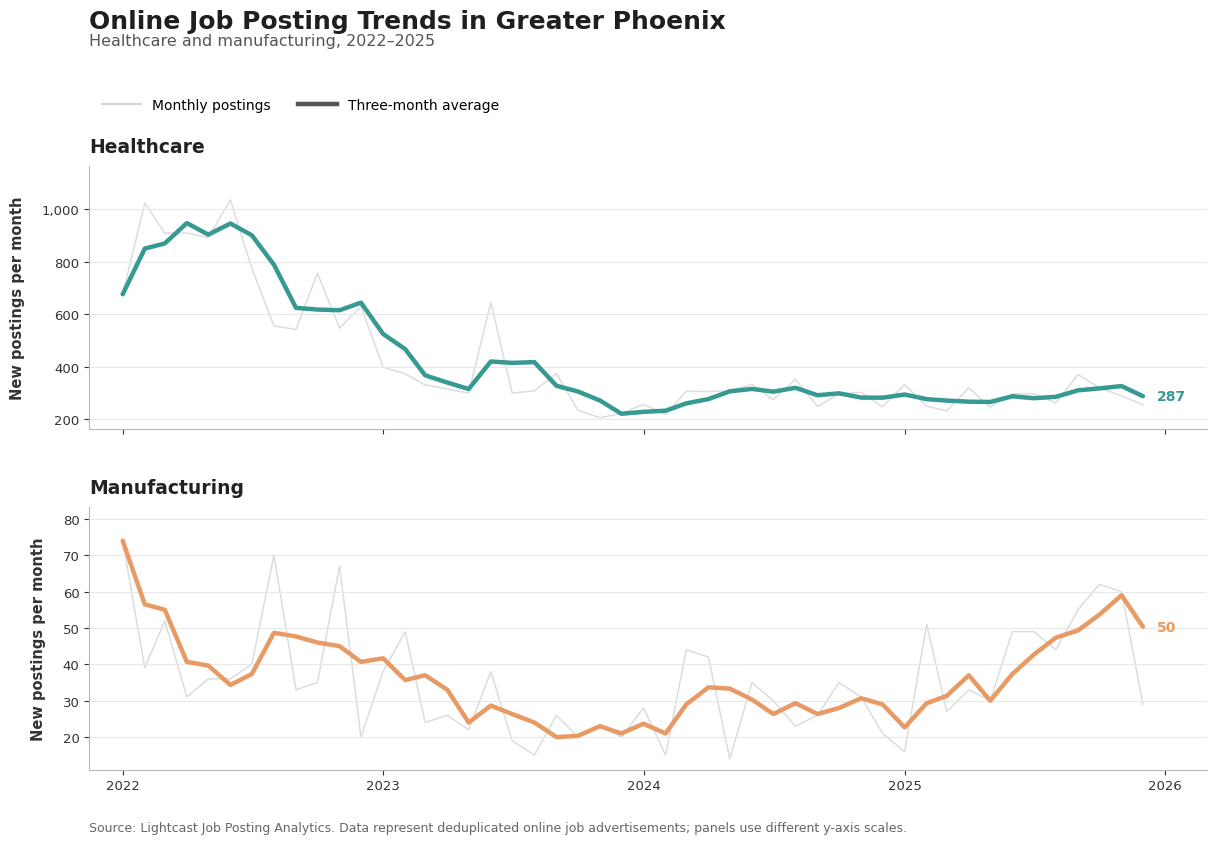

Figure saved to:
C:\Users\301533\Documents\Walmart\Job_Posting_Trends_Greater_Phoenix_2022_2025.png


In [55]:
# ============================================================
# CLEAN PUBLICATION FIGURE
# ONLINE JOB POSTING TRENDS, 2022–2025
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.ticker import StrMethodFormatter
import pandas as pd


# Keep complete calendar years only
plot_data = posting_trends[
    (posting_trends["Month"] >= "2022-01-01")
    & (posting_trends["Month"] <= "2025-12-31")
].copy()


plot_data = plot_data.sort_values(
    [
        "Sector",
        "Month"
    ]
)


# Recalculate the moving average after filtering
plot_data["Three_Month_Average"] = (
    plot_data
    .groupby("Sector")["Unique_Postings"]
    .transform(
        lambda values:
        values.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)


sector_colors = {
    "Healthcare": "#369992",
    "Manufacturing": "#E79A64"
}


sectors = [
    "Healthcare",
    "Manufacturing"
]


# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8.5),
    sharex=True
)


fig.patch.set_facecolor("white")


for axis, sector in zip(
    axes,
    sectors
):

    sector_data = (
        plot_data[
            plot_data["Sector"] == sector
        ]
        .sort_values("Month")
    )


    axis.set_facecolor("white")


    # Monthly observations
    axis.plot(
        sector_data["Month"],
        sector_data["Unique_Postings"],
        color="#CED2D4",
        linewidth=1.1,
        alpha=0.75,
        zorder=1
    )


    # Smoothed trend
    axis.plot(
        sector_data["Month"],
        sector_data["Three_Month_Average"],
        color=sector_colors[sector],
        linewidth=3.2,
        solid_capstyle="round",
        zorder=2
    )


    # Simple panel title
    axis.set_title(
        sector,
        fontsize=13.5,
        fontweight="bold",
        loc="left",
        pad=10,
        color="#222222"
    )


    axis.set_ylabel(
        "New postings per month",
        fontsize=10.5,
        fontweight="bold",
        labelpad=12,
        color="#333333"
    )


    axis.yaxis.set_major_formatter(
        StrMethodFormatter("{x:,.0f}")
    )


    axis.grid(
        axis="y",
        color="#E8E8E8",
        linewidth=0.8
    )


    axis.grid(
        axis="x",
        visible=False
    )


    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    axis.spines["left"].set_color(
        "#B8B8B8"
    )

    axis.spines["bottom"].set_color(
        "#B8B8B8"
    )


    axis.tick_params(
        axis="both",
        labelsize=9.5,
        colors="#333333"
    )


    # Give labels breathing room
    current_bottom, current_top = (
        axis.get_ylim()
    )

    axis.set_ylim(
        bottom=max(0, current_bottom),
        top=current_top * 1.08
    )


    # Label the final three-month average
    latest_row = (
        sector_data
        .dropna(
            subset=["Three_Month_Average"]
        )
        .iloc[-1]
    )


    axis.annotate(
        f"{latest_row['Three_Month_Average']:,.0f}",
        xy=(
            latest_row["Month"],
            latest_row["Three_Month_Average"]
        ),
        xytext=(10, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=sector_colors[sector]
    )


# ============================================================
# X-AXIS
# ============================================================

axes[-1].xaxis.set_major_locator(
    mdates.YearLocator()
)


axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)


axes[-1].set_xlabel("")


axes[-1].set_xlim(
    pd.Timestamp("2021-11-15"),
    pd.Timestamp("2026-03-01")
)


# ============================================================
# SHARED LEGEND
# ============================================================

legend_items = [
    Line2D(
        [0],
        [0],
        color="#CED2D4",
        linewidth=1.3,
        label="Monthly postings"
    ),

    Line2D(
        [0],
        [0],
        color="#555555",
        linewidth=3.2,
        label="Three-month average"
    )
]


fig.legend(
    handles=legend_items,
    loc="upper left",
    bbox_to_anchor=(0.08, 0.895),
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=2.8,
    columnspacing=2.0
)


# ============================================================
# TITLE AND SOURCE
# ============================================================

fig.suptitle(
    "Online Job Posting Trends in Greater Phoenix",
    fontsize=18,
    fontweight="bold",
    x=0.08,
    y=0.985,
    ha="left",
    color="#1F1F1F"
)


fig.text(
    0.08,
    0.943,
    "Healthcare and manufacturing, 2022–2025",
    fontsize=11.5,
    ha="left",
    color="#555555"
)


fig.text(
    0.08,
    0.018,
    "Source: Lightcast Job Posting Analytics. "
    "Data represent deduplicated online job advertisements; "
    "panels use different y-axis scales.",
    fontsize=9,
    ha="left",
    color="#666666"
)


plt.subplots_adjust(
    left=0.08,
    right=0.94,
    top=0.80,
    bottom=0.09,
    hspace=0.30
)


# ============================================================
# SAVE
# ============================================================

figure_path = (
    r"C:\Users\301533\Documents\Walmart"
    r"\Job_Posting_Trends_Greater_Phoenix_2022_2025.png"
)


plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()


print("Figure saved to:")
print(figure_path)

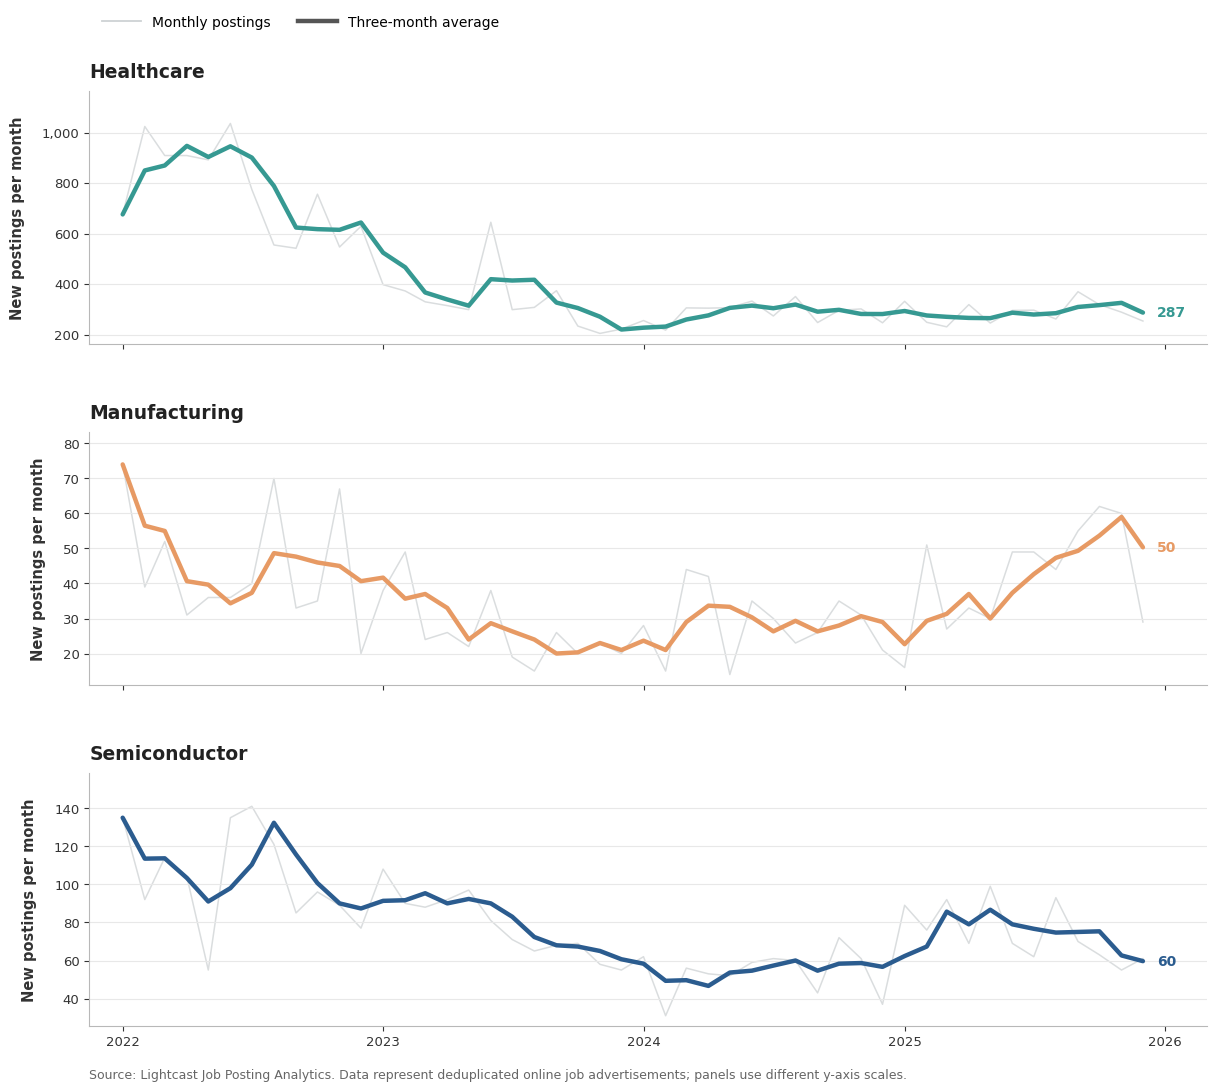

In [90]:
# ============================================================
# EMPLOYER-DEMAND ANALYSIS:
# HEALTHCARE, MANUFACTURING, AND SEMICONDUCTOR JOB POSTINGS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.ticker import StrMethodFormatter
from pathlib import Path


# ============================================================
# 1. FILE PATHS
# ============================================================

semiconductor_file = r"C:\Users\301533\Documents\Walmart\Job_Postings_Table_4_Occupations_in_Phoenix_Mesa_Chandler_AZ_916e15fdc25844c1.csv"

trend_files = {
    "Healthcare": (
        r"C:\Users\301533\Documents\Walmart"
        r"\Job_Posting_Analytics_Health_Care_and_Social_Assistance_in_Phoenix_Mesa_Chandler_AZ_48e6c8b310b722fb.xlsx"
    ),
    "Manufacturing": (
        r"C:\Users\301533\Documents\Walmart"
        r"\Job_Posting_Analytics_Manufacturing_in_Phoenix_Mesa_Chandler_AZ_c9c3dd75cec6d098.xlsx"
    ),
    "Semiconductor": semiconductor_file
}


# ============================================================
# 2. EXTRACT & STRUCTURE HISTORICAL TREND DATA (2018–2025)
# ============================================================

def extract_posting_trend(file, sector):
    # Handle Semiconductor wide CSV structure
    if str(file).endswith('.csv'):
        raw = pd.read_csv(file)
        date_cols = [c for c in raw.columns if 'Unique Postings' in c]
        
        monthly_totals = raw[date_cols].sum(numeric_only=True).reset_index()
        monthly_totals.columns = ["Month_Raw", "Unique_Postings"]
        
        monthly_totals["Month"] = pd.to_datetime(
            monthly_totals["Month_Raw"].str.replace(" Unique Postings", "", regex=False),
            format="%b %Y",
            errors="coerce"
        )
        
        trend = monthly_totals[["Month", "Unique_Postings"]].copy()
        trend["Posting_Intensity"] = np.nan
        
    else:
        # Handle Excel timeseries structure
        trend = pd.read_excel(
            file,
            sheet_name="Job Postings Timeseries",
            header=2
        )
        trend = trend.iloc[:, :3].copy()
        trend.columns = ["Month", "Unique_Postings", "Posting_Intensity"]
        
        trend["Month"] = pd.to_datetime(
            trend["Month"],
            format="%b %Y",
            errors="coerce"
        )
        trend["Unique_Postings"] = pd.to_numeric(
            trend["Unique_Postings"],
            errors="coerce"
        )

    trend = trend.dropna(subset=["Month", "Unique_Postings"])
    trend = trend[
        (trend["Month"] >= "2018-01-01") & 
        (trend["Month"] <= "2025-12-31")
    ].copy()
    
    trend["Sector"] = sector
    return trend


trend_tables = []
for sector, file in trend_files.items():
    trend_tables.append(extract_posting_trend(file, sector))

posting_trends = pd.concat(trend_tables, ignore_index=True)
posting_trends = posting_trends.sort_values(["Sector", "Month"])

posting_trends["Three_Month_Average"] = (
    posting_trends
    .groupby("Sector")["Unique_Postings"]
    .transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )
)


# ============================================================
# 3. BUILD PUBLICATION FIGURE (3 PANELS)
# ============================================================

plot_data = posting_trends[
    (posting_trends["Month"] >= "2022-01-01") & 
    (posting_trends["Month"] <= "2025-12-31")
].copy()

plot_data = plot_data.sort_values(["Sector", "Month"])

plot_data["Three_Month_Average"] = (
    plot_data
    .groupby("Sector")["Unique_Postings"]
    .transform(
        lambda values: values.rolling(window=3, min_periods=1).mean()
    )
)

sector_colors = {
    "Healthcare": "#369992",
    "Manufacturing": "#E79A64",
    "Semiconductor": "#2B5C8F"
}

sectors = ["Healthcare", "Manufacturing", "Semiconductor"]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(13, 11),
    sharex=True
)

fig.patch.set_facecolor("white")

for axis, sector in zip(axes, sectors):

    sector_data = (
        plot_data[plot_data["Sector"] == sector]
        .sort_values("Month")
    )

    axis.set_facecolor("white")

    # Raw monthly line
    axis.plot(
        sector_data["Month"],
        sector_data["Unique_Postings"],
        color="#CED2D4",
        linewidth=1.1,
        alpha=0.75,
        zorder=1
    )

    # Moving average trendline
    axis.plot(
        sector_data["Month"],
        sector_data["Three_Month_Average"],
        color=sector_colors[sector],
        linewidth=3.2,
        solid_capstyle="round",
        zorder=2
    )

    # Panel section title
    axis.set_title(
        sector,
        fontsize=13.5,
        fontweight="bold",
        loc="left",
        pad=10,
        color="#222222"
    )

    axis.set_ylabel(
        "New postings per month",
        fontsize=10.5,
        fontweight="bold",
        labelpad=12,
        color="#333333"
    )

    axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    axis.grid(axis="y", color="#E8E8E8", linewidth=0.8)
    axis.grid(axis="x", visible=False)

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_color("#B8B8B8")
    axis.spines["bottom"].set_color("#B8B8B8")

    axis.tick_params(axis="both", labelsize=9.5, colors="#333333")

    current_bottom, current_top = axis.get_ylim()
    axis.set_ylim(bottom=max(0, current_bottom), top=current_top * 1.08)

    # End value annotation label
    valid_trend = sector_data.dropna(subset=["Three_Month_Average"])
    if not valid_trend.empty:
        latest_row = valid_trend.iloc[-1]
        axis.annotate(
            f"{latest_row['Three_Month_Average']:,.0f}",
            xy=(latest_row["Month"], latest_row["Three_Month_Average"]),
            xytext=(10, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
            color=sector_colors[sector]
        )

# X-axis configuration
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("")
axes[-1].set_xlim(pd.Timestamp("2021-11-15"), pd.Timestamp("2026-03-01"))


# ============================================================
# 4. SHARED LEGEND & FOOTNOTE
# ============================================================

legend_items = [
    Line2D([0], [0], color="#CED2D4", linewidth=1.3, label="Monthly postings"),
    Line2D([0], [0], color="#555555", linewidth=3.2, label="Three-month average")
]

# Elevated legend position clear of the top title margin
fig.legend(
    handles=legend_items,
    loc="lower left",
    bbox_to_anchor=(0.08, 0.955),
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=2.8,
    columnspacing=2.0
)

# Footnote
fig.text(
    0.08,
    0.012,
    "Source: Lightcast Job Posting Analytics. "
    "Data represent deduplicated online job advertisements; "
    "panels use different y-axis scales.",
    fontsize=9,
    ha="left",
    color="#666666"
)

# Spacing adjustment
plt.subplots_adjust(
    left=0.08,
    right=0.94,
    top=0.91,
    bottom=0.06,
    hspace=0.35
)

# Save output
figure_path = r"C:\Users\301533\Documents\Walmart\Job_Posting_Trends_Greater_Phoenix_2022_2025.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [56]:
display(high_growth_occupations_final)

,Sector,SOC,Occupation,Unique_Postings_2024,Unique_Postings_2025,Posting_Change,Posting_Growth_Rate
0,Healthcare,29-1141,Registered Nurses,697.0,968.0,271.0,0.388809
1,Healthcare,31-1128,Home Health and Personal Care Aides,373.0,517.0,144.0,0.386059
2,Healthcare,29-1211,Anesthesiologists,72.0,130.0,58.0,0.805556
3,Healthcare,43-4051,Customer Service Representatives,19.0,44.0,25.0,1.315789
4,Healthcare,29-1122,Occupational Therapists,117.0,140.0,23.0,0.196581
5,Healthcare,31-9097,Phlebotomists,33.0,48.0,15.0,0.454545
6,Healthcare,29-2099,"Health Technologists and Technicians, All Other",14.0,28.0,14.0,1.000000
7,Healthcare,29-1229,"Physicians, All Other",20.0,28.0,8.0,0.400000
8,Healthcare,43-6014,"Secretaries and Administrative Assistants, Exc...",20.0,26.0,6.0,0.300000
9,Healthcare,29-1031,Dietitians and Nutritionists,11.0,15.0,4.0,0.363636


In [57]:
# ============================================================
# MOST RECENT HIGH-GROWTH JOB POSTINGS TABLE
# ============================================================

high_growth_table = (
    high_growth_occupations_final
    .sort_values(
        [
            "Sector",
            "Posting_Change"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby("Sector")
    .head(10)
    .copy()
)


# Add rank within each sector
high_growth_table["Rank"] = (
    high_growth_table
    .groupby("Sector")
    .cumcount()
    + 1
)


# Reorder and rename fields
high_growth_table = high_growth_table[
    [
        "Sector",
        "Rank",
        "SOC",
        "Occupation",
        "Unique_Postings_2024",
        "Unique_Postings_2025",
        "Posting_Change",
        "Posting_Growth_Rate"
    ]
].rename(columns={
    "SOC": "SOC Code",
    "Occupation": "Occupation",
    "Unique_Postings_2024": "2024 Postings",
    "Unique_Postings_2025": "2025 Postings",
    "Posting_Change": "Numeric Change",
    "Posting_Growth_Rate": "Growth Rate"
})


# Display with professional formatting
display(
    high_growth_table.style
    .format({
        "2024 Postings": "{:,.0f}",
        "2025 Postings": "{:,.0f}",
        "Numeric Change": "{:+,.0f}",
        "Growth Rate": "{:+.1%}"
    })
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#369992"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "left")
            ]
        }
    ])
)

Sector,Rank,SOC Code,Occupation,2024 Postings,2025 Postings,Numeric Change,Growth Rate
Healthcare,1,29-1141,Registered Nurses,697,968,+271,+38.9%
Healthcare,2,31-1128,Home Health and Personal Care Aides,373,517,+144,+38.6%
Healthcare,3,29-1211,Anesthesiologists,72,130,+58,+80.6%
Healthcare,4,43-4051,Customer Service Representatives,19,44,+25,+131.6%
Healthcare,5,29-1122,Occupational Therapists,117,140,+23,+19.7%
Healthcare,6,31-9097,Phlebotomists,33,48,+15,+45.5%
Healthcare,7,29-2099,"Health Technologists and Technicians, All Other",14,28,+14,+100.0%
Healthcare,8,29-1229,"Physicians, All Other",20,28,+8,+40.0%
Healthcare,9,43-6014,"Secretaries and Administrative Assistants, Except Legal, Medical, and Executive",20,26,+6,+30.0%
Healthcare,10,29-1031,Dietitians and Nutritionists,11,15,+4,+36.4%


In [59]:
# ============================================================
# EXPORT SEPARATE HEALTHCARE AND MANUFACTURING TABLES
# ============================================================

import pandas as pd

from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment,
    Border,
    Side
)


# ============================================================
# 1. OUTPUT PATH
# ============================================================

output_path = (
    r"C:\Users\301533\Documents\Walmart"
    r"\High_Growth_Job_Postings_by_Industry_2024_2025.xlsx"
)


# ============================================================
# 2. PREPARE SEPARATE TABLES
# ============================================================

healthcare_table = (
    high_growth_table[
        high_growth_table["Sector"]
        == "Healthcare"
    ]
    .drop(columns="Sector")
    .copy()
)


manufacturing_table = (
    high_growth_table[
        high_growth_table["Sector"]
        == "Manufacturing"
    ]
    .drop(columns="Sector")
    .copy()
)


# Reset rank within each table
healthcare_table["Rank"] = range(
    1,
    len(healthcare_table) + 1
)

manufacturing_table["Rank"] = range(
    1,
    len(manufacturing_table) + 1
)


# ============================================================
# 3. FORMATTING FUNCTION
# ============================================================

def format_sector_sheet(
    worksheet,
    title,
    subtitle,
    header_color
):

    number_of_columns = worksheet.max_column
    final_column = chr(
        64 + number_of_columns
    )


    # Title
    worksheet["A1"] = title

    worksheet.merge_cells(
        f"A1:{final_column}1"
    )

    worksheet["A1"].font = Font(
        size=16,
        bold=True,
        color="1F1F1F"
    )

    worksheet["A1"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[1].height = 25


    # Subtitle
    worksheet["A2"] = subtitle

    worksheet.merge_cells(
        f"A2:{final_column}2"
    )

    worksheet["A2"].font = Font(
        size=11,
        italic=True,
        color="666666"
    )


    # Header formatting
    header_row = 4

    header_fill = PatternFill(
        fill_type="solid",
        fgColor=header_color
    )

    header_font = Font(
        bold=True,
        color="FFFFFF"
    )


    for cell in worksheet[header_row]:

        cell.fill = header_fill
        cell.font = header_font

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )


    worksheet.row_dimensions[
        header_row
    ].height = 35


    # Alternating row formatting
    gray_fill = PatternFill(
        fill_type="solid",
        fgColor="F2F2F2"
    )

    bottom_border = Border(
        bottom=Side(
            style="thin",
            color="D8D8D8"
        )
    )


    for row in range(
        header_row + 1,
        worksheet.max_row + 1
    ):

        if row % 2 == 1:

            for cell in worksheet[row]:
                cell.fill = gray_fill


        for cell in worksheet[row]:

            cell.border = bottom_border

            cell.alignment = Alignment(
                vertical="center"
            )


    # Find columns based on headers
    header_lookup = {
        worksheet.cell(
            row=header_row,
            column=column
        ).value: column

        for column in range(
            1,
            worksheet.max_column + 1
        )
    }


    # Whole-number formats
    for header in [
        "Rank",
        "2024 Postings",
        "2025 Postings"
    ]:

        if header in header_lookup:

            column = header_lookup[header]

            for row in range(
                header_row + 1,
                worksheet.max_row + 1
            ):

                worksheet.cell(
                    row=row,
                    column=column
                ).number_format = '#,##0'


    # Numeric change with signs
    if "Numeric Change" in header_lookup:

        column = header_lookup[
            "Numeric Change"
        ]

        for row in range(
            header_row + 1,
            worksheet.max_row + 1
        ):

            worksheet.cell(
                row=row,
                column=column
            ).number_format = (
                '+#,##0;-#,##0;0'
            )


    # Growth rate with signs
    if "Growth Rate" in header_lookup:

        column = header_lookup[
            "Growth Rate"
        ]

        for row in range(
            header_row + 1,
            worksheet.max_row + 1
        ):

            worksheet.cell(
                row=row,
                column=column
            ).number_format = (
                '+0.0%;-0.0%;0.0%'
            )


    # Column widths
    column_widths = {
        "A": 9,    # Rank
        "B": 13,   # SOC
        "C": 48,   # Occupation
        "D": 16,   # 2024 postings
        "E": 16,   # 2025 postings
        "F": 16,   # Numeric change
        "G": 14    # Growth rate
    }


    for column, width in column_widths.items():

        worksheet.column_dimensions[
            column
        ].width = width


    # Freeze and filter
    worksheet.freeze_panes = "A5"

    worksheet.auto_filter.ref = (
        f"A{header_row}:"
        f"{final_column}{worksheet.max_row}"
    )


    # Source note
    note_row = worksheet.max_row + 2

    worksheet.cell(
        row=note_row,
        column=1
    ).value = (
        "Source: Lightcast Job Posting Analytics. "
        "Includes occupations with at least 10 postings "
        "in 2024 and positive posting growth in 2025."
    )

    worksheet.merge_cells(
        start_row=note_row,
        start_column=1,
        end_row=note_row,
        end_column=number_of_columns
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).font = Font(
        size=9,
        italic=True,
        color="666666"
    )


# ============================================================
# 4. WRITE EXCEL WORKBOOK
# ============================================================

with pd.ExcelWriter(
    output_path,
    engine="openpyxl"
) as writer:

    healthcare_table.to_excel(
        writer,
        sheet_name="Healthcare",
        index=False,
        startrow=3
    )


    manufacturing_table.to_excel(
        writer,
        sheet_name="Manufacturing",
        index=False,
        startrow=3
    )


    format_sector_sheet(
        writer.sheets["Healthcare"],
        "High-Growth Healthcare Occupations",
        "Newly posted online job advertisements "
        "in Greater Phoenix, 2024–2025",
        "369992"
    )


    format_sector_sheet(
        writer.sheets["Manufacturing"],
        "High-Growth Manufacturing Occupations",
        "Newly posted online job advertisements "
        "in Greater Phoenix, 2024–2025",
        "E79A64"
    )


print("Excel workbook saved to:")
print(output_path)

Excel workbook saved to:
C:\Users\301533\Documents\Walmart\High_Growth_Job_Postings_by_Industry_2024_2025.xlsx


In [60]:
manufacturing_check = (
    occupation_growth[
        occupation_growth["Sector"]
        == "Manufacturing"
    ][
        [
            "SOC",
            "Occupation",
            "Unique_Postings_2024",
            "Unique_Postings_2025",
            "Posting_Change",
            "Posting_Growth_Rate",
            "Data_Status"
        ]
    ]
    .sort_values(
        "Posting_Change",
        ascending=False,
        na_position="last"
    )
)

display(manufacturing_check)

,SOC,Occupation,Unique_Postings_2024,Unique_Postings_2025,Posting_Change,Posting_Growth_Rate,Data_Status
126,11-2022,Sales Managers,2.0,30.0,28.0,14.000000,Available in both years
107,13-1161,Market Research Analysts and Marketing Special...,1.0,24.0,23.0,23.000000,Available in both years
128,41-4012,"Sales Representatives, Wholesale and Manufactu...",3.0,26.0,23.0,7.666667,Available in both years
133,15-1252,Software Developers,10.0,26.0,16.0,1.600000,Available in both years
94,53-3032,Heavy and Tractor-Trailer Truck Drivers,2.0,17.0,15.0,7.500000,Available in both years
...,...,...,...,...,...,...,...
134,15-1253,Software Quality Assurance Analysts and Testers,1.0,NaN,NaN,NaN,Not in exported 2025 top occupations
135,53-7065,Stockers and Order Fillers,6.0,NaN,NaN,NaN,Not in exported 2025 top occupations
136,13-1151,Training and Development Specialists,NaN,4.0,NaN,NaN,Not in exported 2024 top occupations
137,11-3071,"Transportation, Storage, and Distribution Mana...",NaN,2.0,NaN,NaN,Not in exported 2024 top occupations


In [63]:
# ============================================================
# MOST-POSTED OCCUPATIONS AND RECENT CHANGE
# ============================================================

demand_table = (
    occupation_growth
    .dropna(
        subset=["Unique_Postings_2025"]
    )
    .sort_values(
        [
            "Sector",
            "Unique_Postings_2025"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby("Sector")
    .head(10)
    .copy()
)


demand_table["Rank"] = (
    demand_table
    .groupby("Sector")
    .cumcount()
    + 1
)


demand_table = demand_table[
    [
        "Sector",
        "Rank",
        "SOC",
        "Occupation",
        "Unique_Postings_2024",
        "Unique_Postings_2025",
        "Posting_Change",
        "Posting_Growth_Rate"
    ]
].rename(columns={
    "SOC": "SOC Code",
    "Unique_Postings_2024": "2024 Postings",
    "Unique_Postings_2025": "2025 Postings",
    "Posting_Change": "Numeric Change",
    "Posting_Growth_Rate": "Growth Rate"
})


display(demand_table)

,Sector,Rank,SOC Code,Occupation,2024 Postings,2025 Postings,Numeric Change,Growth Rate
51,Healthcare,1,29-1141,Registered Nurses,697.0,968.0,271.0,0.388809
27,Healthcare,2,31-1128,Home Health and Personal Care Aides,373.0,517.0,144.0,0.386059
40,Healthcare,3,29-1122,Occupational Therapists,117.0,140.0,23.0,0.196581
0,Healthcare,4,29-1211,Anesthesiologists,72.0,130.0,58.0,0.805556
44,Healthcare,5,29-1123,Physical Therapists,126.0,114.0,-12.0,-0.095238
60,Healthcare,6,25-2059,"Special Education Teachers, All Other",243.0,83.0,-160.0,-0.658436
7,Healthcare,7,13-1141,"Compensation, Benefits, and Job Analysis Speci...",NaN,73.0,NaN,NaN
5,Healthcare,8,29-2018,Clinical Laboratory Technologists and Technicians,98.0,70.0,-28.0,-0.285714
49,Healthcare,9,29-2034,Radiologic Technologists and Technicians,117.0,62.0,-55.0,-0.470085
31,Healthcare,10,29-2035,Magnetic Resonance Imaging Technologists,62.0,60.0,-2.0,-0.032258


In [70]:
# ============================================================
# CREATE AND EXPORT SEPARATE EMPLOYER-DEMAND TABLES
# ============================================================

import os
import numpy as np
import pandas as pd

from IPython.display import display, HTML
from openpyxl.styles import (
    Font,
    PatternFill,
    Border,
    Side,
    Alignment
)
from openpyxl.utils import get_column_letter


# ============================================================
# 1. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Sector",
    "SOC Code",
    "Occupation",
    "2024 Postings",
    "2025 Postings",
    "Numeric Change",
    "Growth Rate"
]

missing_columns = [
    column
    for column in required_columns
    if column not in demand_table.columns
]

if missing_columns:
    raise KeyError(
        "These columns are missing from demand_table: "
        + ", ".join(missing_columns)
    )


# ============================================================
# ============================================================
# 2. PREPARE THE DATA
# ============================================================

report_demand_table = demand_table.copy()

numeric_columns = [
    "2024 Postings",
    "2025 Postings"
]

for column in numeric_columns:
    report_demand_table[column] = pd.to_numeric(
        report_demand_table[column],
        errors="coerce"
    )


# Recalculate numeric and percentage changes whenever
# both annual posting counts are available.
report_demand_table["Numeric Change"] = (
    report_demand_table["2025 Postings"]
    - report_demand_table["2024 Postings"]
)

report_demand_table["Growth Rate"] = np.where(
    report_demand_table["2024 Postings"].gt(0),
    (
        report_demand_table["2025 Postings"]
        - report_demand_table["2024 Postings"]
    )
    / report_demand_table["2024 Postings"],
    np.nan
)

# ============================================================
# 3. FUNCTION TO CREATE EACH SECTOR TABLE
# ============================================================
def create_sector_table(data, sector, number_of_rows=10):

    sector_table = data.loc[
        data["Sector"].eq(sector),
        [
            "SOC Code",
            "Occupation",
            "2024 Postings",
            "2025 Postings",
            "Numeric Change",
            "Growth Rate"
        ]
    ].copy()

    # A high-growth occupation must:
    # 1. Have data in both years
    # 2. Have more postings in 2025 than in 2024
    sector_table = sector_table[
        sector_table["2024 Postings"].notna()
        & sector_table["2025 Postings"].notna()
        & sector_table["Numeric Change"].gt(0)
    ]

    # Rank primarily by the number of additional postings.
    sector_table = (
        sector_table
        .sort_values(
            by=[
                "Numeric Change",
                "2025 Postings",
                "Growth Rate"
            ],
            ascending=[False, False, False]
        )
        .head(number_of_rows)
        .reset_index(drop=True)
    )

    sector_table.insert(
        0,
        "Rank",
        range(1, len(sector_table) + 1)
    )

    return sector_table


healthcare_table = create_sector_table(
    report_demand_table,
    sector="Healthcare",
    number_of_rows=10
)

manufacturing_table = create_sector_table(
    report_demand_table,
    sector="Manufacturing",
    number_of_rows=10
)


# ============================================================
# 4. NOTE FOR THE TABLES
# ============================================================

table_note = (
    "Source: Lightcast Job Posting Analytics. Counts represent newly "
    "posted online job advertisements in Greater Phoenix. Numeric and "
    "percentage changes compare 2025 with 2024. A blank indicates that "
    "the occupation was not included in one of the annual Lightcast "
    "top-occupation exports; the missing value was not treated as zero."
)

# ============================================================
# 5. NOTEBOOK TABLE FORMATTING FUNCTION
# ============================================================

def display_sector_table(table, sector, color):

    display(
        HTML(
            f"""
            <div style="
                margin-top:20px;
                margin-bottom:8px;
                font-family:Arial, sans-serif;
            ">
                <div style="
                    font-size:20px;
                    font-weight:bold;
                    color:#222222;
                ">
                    Most-Posted {sector} Occupations, 2025
                </div>

                <div style="
                    font-size:13px;
                    color:#666666;
                    margin-top:3px;
                ">
                    Newly posted online job advertisements in Greater
                    Phoenix; change compares 2025 with 2024
                </div>
            </div>
            """
        )
    )

    styled_table = (
        table.style
        .hide(axis="index")
        .format(
            {
                "Rank": "{:.0f}",
                "2024 Postings": "{:,.0f}",
                "2025 Postings": "{:,.0f}",
                "Numeric Change": "{:+,.0f}",
                "Growth Rate": "{:+.1%}"
            },
            na_rep="—"
        )
        .set_table_styles(
            [
                {
                    "selector": "table",
                    "props": [
                        ("border-collapse", "collapse"),
                        ("font-family", "Arial, sans-serif"),
                        ("font-size", "12px"),
                        ("width", "100%")
                    ]
                },
                {
                    "selector": "th",
                    "props": [
                        ("background-color", color),
                        ("color", "white"),
                        ("font-weight", "bold"),
                        ("text-align", "center"),
                        ("padding", "8px"),
                        ("border", "1px solid #D9D9D9")
                    ]
                },
                {
                    "selector": "td",
                    "props": [
                        ("padding", "7px"),
                        ("border-bottom", "1px solid #E5E5E5")
                    ]
                },
                {
                    "selector": "tbody tr:nth-child(even)",
                    "props": [
                        ("background-color", "#F7F7F7")
                    ]
                }
            ]
        )
        .set_properties(
            subset=["Occupation"],
            **{
                "text-align": "left"
            }
        )
        .set_properties(
            subset=[
                "Rank",
                "SOC Code",
                "2024 Postings",
                "2025 Postings",
                "Numeric Change",
                "Growth Rate"
            ],
            **{
                "text-align": "center"
            }
        )
    )

    display(styled_table)

    display(
        HTML(
            f"""
            <div style="
                font-family:Arial, sans-serif;
                font-size:11px;
                color:#666666;
                margin-top:7px;
                margin-bottom:20px;
            ">
                {table_note}
            </div>
            """
        )
    )


# ============================================================
# 6. DISPLAY THE TWO TABLES
# ============================================================

display_sector_table(
    healthcare_table,
    sector="Healthcare",
    color="#369992"
)

display_sector_table(
    manufacturing_table,
    sector="Manufacturing",
    color="#E79A64"
)


# ============================================================
# 7. EXCEL OUTPUT LOCATION
# ============================================================

output_path = (
    r"C:\Users\301533\Documents\Walmart"
    r"\Most_Posted_Occupations_by_Industry_2025.xlsx"
)

os.makedirs(
    os.path.dirname(output_path),
    exist_ok=True
)


# ============================================================
# 8. EXCEL FORMATTING FUNCTION
# ============================================================

def format_excel_sheet(
    worksheet,
    table,
    title,
    header_color
):

    number_of_columns = len(table.columns)
    last_column_letter = get_column_letter(number_of_columns)

    # --------------------------------------------------------
    # Title and subtitle
    # --------------------------------------------------------

    worksheet.merge_cells(
        f"A1:{last_column_letter}1"
    )

    worksheet["A1"] = title

    worksheet["A1"].font = Font(
        name="Aptos Display",
        size=18,
        bold=True,
        color="FFFFFF"
    )

    worksheet["A1"].fill = PatternFill(
        fill_type="solid",
        fgColor=header_color
    )

    worksheet["A1"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[1].height = 30

    worksheet.merge_cells(
        f"A2:{last_column_letter}2"
    )

    worksheet["A2"] = (
        "Newly posted online job advertisements in Greater Phoenix; "
        "change compares 2025 with 2024"
    )

    worksheet["A2"].font = Font(
        name="Aptos",
        size=10,
        italic=True,
        color="666666"
    )

    worksheet["A2"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[2].height = 22

    # --------------------------------------------------------
    # Header row
    # --------------------------------------------------------

    header_row = 4

    header_fill = PatternFill(
        fill_type="solid",
        fgColor=header_color
    )

    header_font = Font(
        name="Aptos",
        size=10,
        bold=True,
        color="FFFFFF"
    )

    thin_gray_border = Border(
        bottom=Side(
            style="thin",
            color="D9D9D9"
        )
    )

    for cell in worksheet[header_row]:

        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

    worksheet.row_dimensions[header_row].height = 32

    # --------------------------------------------------------
    # Data rows
    # --------------------------------------------------------

    first_data_row = header_row + 1
    last_data_row = header_row + len(table)

    for row_number in range(
        first_data_row,
        last_data_row + 1
    ):

        # Alternate row shading
        if (row_number - first_data_row) % 2 == 1:
            row_fill = PatternFill(
                fill_type="solid",
                fgColor="F4F4F4"
            )
        else:
            row_fill = PatternFill(
                fill_type="solid",
                fgColor="FFFFFF"
            )

        for column_number in range(
            1,
            number_of_columns + 1
        ):

            cell = worksheet.cell(
                row=row_number,
                column=column_number
            )

            cell.fill = row_fill
            cell.border = thin_gray_border
            cell.font = Font(
                name="Aptos",
                size=10,
                color="222222"
            )

            if column_number == 3:
                cell.alignment = Alignment(
                    horizontal="left",
                    vertical="center",
                    wrap_text=True
                )
            else:
                cell.alignment = Alignment(
                    horizontal="center",
                    vertical="center"
                )

        worksheet.row_dimensions[row_number].height = 28

    # --------------------------------------------------------
    # Number formats
    # --------------------------------------------------------

    for row_number in range(
        first_data_row,
        last_data_row + 1
    ):

        # Rank
        worksheet.cell(
            row=row_number,
            column=1
        ).number_format = "0"

        # Posting counts
        worksheet.cell(
            row=row_number,
            column=4
        ).number_format = "#,##0"

        worksheet.cell(
            row=row_number,
            column=5
        ).number_format = "#,##0"

        # Numeric change with plus/minus signs
        worksheet.cell(
            row=row_number,
            column=6
        ).number_format = "+#,##0;-#,##0;0"

        # Percentage change
        worksheet.cell(
            row=row_number,
            column=7
        ).number_format = "+0.0%;-0.0%;0.0%"

    # --------------------------------------------------------
    # Column widths
    # --------------------------------------------------------

    column_widths = {
        "A": 8,
        "B": 13,
        "C": 52,
        "D": 16,
        "E": 16,
        "F": 17,
        "G": 15
    }

    for column_letter, width in column_widths.items():
        worksheet.column_dimensions[
            column_letter
        ].width = width

    # --------------------------------------------------------
    # Freeze panes and filters
    # --------------------------------------------------------

    worksheet.freeze_panes = "A5"

    worksheet.auto_filter.ref = (
        f"A4:{last_column_letter}{last_data_row}"
    )

    # --------------------------------------------------------
    # Source and methodology note
    # --------------------------------------------------------

    note_row = last_data_row + 2

    worksheet.merge_cells(
        f"A{note_row}:{last_column_letter}{note_row + 1}"
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).value = table_note

    worksheet.cell(
        row=note_row,
        column=1
    ).font = Font(
        name="Aptos",
        size=9,
        italic=True,
        color="666666"
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).alignment = Alignment(
        horizontal="left",
        vertical="top",
        wrap_text=True
    )

    worksheet.row_dimensions[note_row].height = 22
    worksheet.row_dimensions[note_row + 1].height = 18

    # --------------------------------------------------------
    # Sheet and print settings
    # --------------------------------------------------------

    worksheet.sheet_view.showGridLines = False

    worksheet.print_title_rows = "$1:$4"

    worksheet.page_setup.orientation = "landscape"
    worksheet.page_setup.fitToWidth = 1
    worksheet.page_setup.fitToHeight = 0

    worksheet.sheet_properties.pageSetUpPr.fitToPage = True

    worksheet.page_margins.left = 0.25
    worksheet.page_margins.right = 0.25
    worksheet.page_margins.top = 0.50
    worksheet.page_margins.bottom = 0.50


# ============================================================
# 9. WRITE THE EXCEL WORKBOOK
# ============================================================

from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

output_path = (
    rf"C:\Users\301533\Documents\Walmart"
    rf"\High_Growth_Occupations_2024_2025_{timestamp}.xlsx"
)

print("Attempting to save workbook to:")
print(output_path)

with pd.ExcelWriter(
    output_path,
    engine="openpyxl"
) as writer:

    healthcare_table.to_excel(
        writer,
        sheet_name="Healthcare",
        index=False,
        startrow=3
    )

    manufacturing_table.to_excel(
        writer,
        sheet_name="Manufacturing",
        index=False,
        startrow=3
    )

    healthcare_sheet = writer.sheets["Healthcare"]
    manufacturing_sheet = writer.sheets["Manufacturing"]

    format_excel_sheet(
        worksheet=healthcare_sheet,
        table=healthcare_table,
        title="High-Growth Healthcare Occupations, 2024–2025",
        header_color="369992"
    )

    format_excel_sheet(
        worksheet=manufacturing_sheet,
        table=manufacturing_table,
        title="High-Growth Manufacturing Occupations, 2024–2025",
        header_color="E79A64"
    )


print("\nWorkbook successfully saved to:")
print(output_path)

# ============================================================
# 10. CONFIRM THE OUTPUT
# ============================================================

print("=" * 70)
print("TABLES CREATED")
print("=" * 70)

print("\nHealthcare rows:", len(healthcare_table))
print("Manufacturing rows:", len(manufacturing_table))

print("\nWorkbook saved to:")
print(output_path)

Rank,SOC Code,Occupation,2024 Postings,2025 Postings,Numeric Change,Growth Rate
1,29-1141,Registered Nurses,697,968,+271,+38.9%
2,31-1128,Home Health and Personal Care Aides,373,517,+144,+38.6%
3,29-1211,Anesthesiologists,72,130,+58,+80.6%
4,29-1122,Occupational Therapists,117,140,+23,+19.7%


Rank,SOC Code,Occupation,2024 Postings,2025 Postings,Numeric Change,Growth Rate
1,11-2022,Sales Managers,2,30,+28,+1400.0%
2,41-4012,"Sales Representatives, Wholesale and Manufacturing, Except Technical and Scientific Products",3,26,+23,+766.7%
3,13-1161,Market Research Analysts and Marketing Specialists,1,24,+23,+2300.0%
4,15-1252,Software Developers,10,26,+16,+160.0%
5,53-3032,Heavy and Tractor-Trailer Truck Drivers,2,17,+15,+750.0%
6,11-2021,Marketing Managers,1,16,+15,+1500.0%
7,15-1299,"Computer Occupations, All Other",4,13,+9,+225.0%
8,11-3031,Financial Managers,2,11,+9,+450.0%


Attempting to save workbook to:
C:\Users\301533\Documents\Walmart\High_Growth_Occupations_2024_2025_20260915_162033.xlsx

Workbook successfully saved to:
C:\Users\301533\Documents\Walmart\High_Growth_Occupations_2024_2025_20260915_162033.xlsx
TABLES CREATED

Healthcare rows: 4
Manufacturing rows: 8

Workbook saved to:
C:\Users\301533\Documents\Walmart\High_Growth_Occupations_2024_2025_20260915_162033.xlsx


In [74]:
# ============================================================
# BUILD THE TABLES FROM THE FULL OCCUPATION-GROWTH DATA
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. VERIFY THE FULL DATAFRAME EXISTS
# ============================================================

if "occupation_growth" not in globals():
    raise NameError(
        "occupation_growth does not exist. Run the earlier code that "
        "merges the 2024 and 2025 occupation posting files first."
    )


required_columns = [
    "Sector",
    "SOC",
    "Occupation",
    "Unique_Postings_2024",
    "Unique_Postings_2025"
]

missing_columns = [
    column
    for column in required_columns
    if column not in occupation_growth.columns
]

if missing_columns:
    raise KeyError(
        "Missing columns in occupation_growth: "
        + ", ".join(missing_columns)
    )


# ============================================================
# 2. PREPARE THE FULL OCCUPATION DATA
# ============================================================

posting_data = occupation_growth[
    [
        "Sector",
        "SOC",
        "Occupation",
        "Unique_Postings_2024",
        "Unique_Postings_2025"
    ]
].copy()


posting_data = posting_data.rename(
    columns={
        "SOC": "SOC Code",
        "Unique_Postings_2024": "2024 Postings",
        "Unique_Postings_2025": "2025 Postings"
    }
)


posting_data["Sector"] = (
    posting_data["Sector"]
    .astype(str)
    .str.strip()
)

posting_data["SOC Code"] = (
    posting_data["SOC Code"]
    .astype(str)
    .str.strip()
)

posting_data["Occupation"] = (
    posting_data["Occupation"]
    .astype(str)
    .str.strip()
)

posting_data["2024 Postings"] = pd.to_numeric(
    posting_data["2024 Postings"],
    errors="coerce"
)

posting_data["2025 Postings"] = pd.to_numeric(
    posting_data["2025 Postings"],
    errors="coerce"
)


# Calculate year-over-year change.
posting_data["Numeric Change"] = (
    posting_data["2025 Postings"]
    - posting_data["2024 Postings"]
)

posting_data["Growth Rate"] = np.where(
    posting_data["2024 Postings"] > 0,
    posting_data["Numeric Change"]
    / posting_data["2024 Postings"],
    np.nan
)


# ============================================================
# 3. CREATE 10 COMPLETE OCCUPATIONS FOR EACH INDUSTRY
# ============================================================

def create_complete_sector_table(
    data,
    sector,
    number_of_rows=10
):

    sector_table = data.loc[
        data["Sector"].eq(sector),
        [
            "SOC Code",
            "Occupation",
            "2024 Postings",
            "2025 Postings",
            "Numeric Change",
            "Growth Rate"
        ]
    ].copy()

    # Retain only records that can support a valid comparison.
    sector_table = sector_table.dropna(
        subset=[
            "SOC Code",
            "Occupation",
            "2024 Postings",
            "2025 Postings",
            "Numeric Change",
            "Growth Rate"
        ]
    )

    sector_table = sector_table[
        sector_table["2024 Postings"] > 0
    ]

    sector_table = sector_table.drop_duplicates(
        subset=["SOC Code"],
        keep="first"
    )

    # Select the leading occupations based on 2025 postings.
    sector_table = (
        sector_table
        .sort_values(
            by=[
                "2025 Postings",
                "Numeric Change"
            ],
            ascending=[
                False,
                False
            ]
        )
        .head(number_of_rows)
        .reset_index(drop=True)
    )

    if len(sector_table) < number_of_rows:
        raise ValueError(
            f"The complete occupation_growth data contains only "
            f"{len(sector_table)} usable {sector} occupations."
        )

    sector_table.insert(
        0,
        "Rank",
        range(1, len(sector_table) + 1)
    )

    return sector_table


healthcare_table = create_complete_sector_table(
    data=posting_data,
    sector="Healthcare",
    number_of_rows=10
)

manufacturing_table = create_complete_sector_table(
    data=posting_data,
    sector="Manufacturing",
    number_of_rows=10
)


# ============================================================
# 4. VERIFY THE RESULTS BEFORE EXPORTING
# ============================================================

print("=" * 70)
print("HEALTHCARE TABLE")
print("=" * 70)

display(healthcare_table)

print("\nRows:", len(healthcare_table))
print(
    "Missing values:",
    healthcare_table.isna().sum().sum()
)


print("\n" + "=" * 70)
print("MANUFACTURING TABLE")
print("=" * 70)

display(manufacturing_table)

print("\nRows:", len(manufacturing_table))
print(
    "Missing values:",
    manufacturing_table.isna().sum().sum()
)


assert len(healthcare_table) == 10
assert len(manufacturing_table) == 10

assert healthcare_table.isna().sum().sum() == 0
assert manufacturing_table.isna().sum().sum() == 0


# ============================================================
# 5. SET THE OUTPUT PATH
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

output_directory = (
    r"C:\Users\301533\Documents\Walmart"
)

os.makedirs(
    output_directory,
    exist_ok=True
)

output_path = os.path.join(
    output_directory,
    f"Leading_Occupations_Online_Postings_"
    f"2024_2025_{timestamp}.xlsx"
)


# ============================================================
# 6. EXCEL FORMATTING FUNCTION
# ============================================================

def format_sector_sheet(
    worksheet,
    table,
    sector,
    color
):

    title = (
        f"Leading {sector} Occupations in "
        f"Online Job Postings, 2025"
    )

    subtitle = (
        "Newly posted online job advertisements in Greater Phoenix; "
        "change compares 2025 with 2024"
    )

    source_note = (
        "Source: Lightcast Job Posting Analytics. The table includes "
        "occupations with available posting counts in both 2024 and "
        "2025 and ranks them by 2025 posting volume. Online job "
        "advertisements do not represent all vacancies or hires."
    )

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    worksheet.merge_cells("A1:G1")
    worksheet["A1"] = title

    worksheet["A1"].font = Font(
        name="Aptos Display",
        size=17,
        bold=True,
        color="FFFFFF"
    )

    worksheet["A1"].fill = PatternFill(
        fill_type="solid",
        fgColor=color
    )

    worksheet["A1"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[1].height = 30

    # --------------------------------------------------------
    # Subtitle
    # --------------------------------------------------------

    worksheet.merge_cells("A2:G2")
    worksheet["A2"] = subtitle

    worksheet["A2"].font = Font(
        name="Aptos",
        size=10,
        italic=True,
        color="595959"
    )

    worksheet["A2"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[2].height = 22

    # --------------------------------------------------------
    # Column headers
    # --------------------------------------------------------

    header_row = 4

    header_fill = PatternFill(
        fill_type="solid",
        fgColor=color
    )

    header_font = Font(
        name="Aptos",
        size=10,
        bold=True,
        color="FFFFFF"
    )

    for cell in worksheet[header_row]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

    worksheet.row_dimensions[header_row].height = 32

    # --------------------------------------------------------
    # Data rows
    # --------------------------------------------------------

    first_data_row = 5
    last_data_row = 4 + len(table)

    bottom_border = Border(
        bottom=Side(
            style="thin",
            color="D9D9D9"
        )
    )

    for row_number in range(
        first_data_row,
        last_data_row + 1
    ):

        if row_number % 2 == 0:
            row_color = "F2F2F2"
        else:
            row_color = "FFFFFF"

        row_fill = PatternFill(
            fill_type="solid",
            fgColor=row_color
        )

        for column_number in range(1, 8):

            cell = worksheet.cell(
                row=row_number,
                column=column_number
            )

            cell.fill = row_fill
            cell.border = bottom_border

            cell.font = Font(
                name="Aptos",
                size=10,
                color="222222"
            )

            if column_number == 3:
                cell.alignment = Alignment(
                    horizontal="left",
                    vertical="center",
                    wrap_text=True
                )
            else:
                cell.alignment = Alignment(
                    horizontal="center",
                    vertical="center"
                )

        worksheet.row_dimensions[row_number].height = 30

    # --------------------------------------------------------
    # Number formats
    # --------------------------------------------------------

    for row_number in range(
        first_data_row,
        last_data_row + 1
    ):

        # Rank
        worksheet.cell(
            row=row_number,
            column=1
        ).number_format = "0"

        # Posting counts
        worksheet.cell(
            row=row_number,
            column=4
        ).number_format = "#,##0"

        worksheet.cell(
            row=row_number,
            column=5
        ).number_format = "#,##0"

        # Numeric change
        worksheet.cell(
            row=row_number,
            column=6
        ).number_format = "+#,##0;-#,##0;0"

        # Growth rate
        worksheet.cell(
            row=row_number,
            column=7
        ).number_format = "+0.0%;-0.0%;0.0%"

    # --------------------------------------------------------
    # Column widths
    # --------------------------------------------------------

    column_widths = {
        "A": 8,
        "B": 13,
        "C": 55,
        "D": 16,
        "E": 16,
        "F": 17,
        "G": 15
    }

    for column_letter, width in column_widths.items():
        worksheet.column_dimensions[
            column_letter
        ].width = width

    # --------------------------------------------------------
    # Source note
    # --------------------------------------------------------

    note_row = last_data_row + 2

    worksheet.merge_cells(
        start_row=note_row,
        start_column=1,
        end_row=note_row + 1,
        end_column=7
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).value = source_note

    worksheet.cell(
        row=note_row,
        column=1
    ).font = Font(
        name="Aptos",
        size=9,
        italic=True,
        color="666666"
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).alignment = Alignment(
        horizontal="left",
        vertical="top",
        wrap_text=True
    )

    worksheet.row_dimensions[note_row].height = 22
    worksheet.row_dimensions[note_row + 1].height = 18

    # --------------------------------------------------------
    # Sheet settings
    # --------------------------------------------------------

    worksheet.freeze_panes = "A5"

    worksheet.auto_filter.ref = (
        f"A4:G{last_data_row}"
    )

    worksheet.sheet_view.showGridLines = False

    worksheet.print_title_rows = "$1:$4"

    worksheet.page_setup.orientation = "landscape"
    worksheet.page_setup.fitToWidth = 1
    worksheet.page_setup.fitToHeight = 0

    worksheet.sheet_properties.pageSetUpPr.fitToPage = True

    worksheet.page_margins.left = 0.25
    worksheet.page_margins.right = 0.25
    worksheet.page_margins.top = 0.50
    worksheet.page_margins.bottom = 0.50


# ============================================================
# 7. EXPORT THE WORKBOOK
# ============================================================

with pd.ExcelWriter(
    output_path,
    engine="openpyxl"
) as writer:

    healthcare_table.to_excel(
        writer,
        sheet_name="Healthcare",
        index=False,
        startrow=3
    )

    manufacturing_table.to_excel(
        writer,
        sheet_name="Manufacturing",
        index=False,
        startrow=3
    )

    healthcare_sheet = writer.sheets["Healthcare"]
    manufacturing_sheet = writer.sheets["Manufacturing"]

    format_sector_sheet(
        worksheet=healthcare_sheet,
        table=healthcare_table,
        sector="Healthcare",
        color="369992"
    )

    format_sector_sheet(
        worksheet=manufacturing_sheet,
        table=manufacturing_table,
        sector="Manufacturing",
        color="E79A64"
    )


# ============================================================
# 8. CONFIRM SUCCESS
# ============================================================

print("\n" + "=" * 70)
print("WORKBOOK SUCCESSFULLY EXPORTED")
print("=" * 70)

print("\nHealthcare rows:", len(healthcare_table))
print("Manufacturing rows:", len(manufacturing_table))

print("\nSaved to:")
print(output_path)

HEALTHCARE TABLE


,Rank,SOC Code,Occupation,2024 Postings,2025 Postings,Numeric Change,Growth Rate
0,1,29-1141,Registered Nurses,697.0,968.0,271.0,0.388809
1,2,31-1128,Home Health and Personal Care Aides,373.0,517.0,144.0,0.386059
2,3,29-1122,Occupational Therapists,117.0,140.0,23.0,0.196581
3,4,29-1211,Anesthesiologists,72.0,130.0,58.0,0.805556
4,5,29-1123,Physical Therapists,126.0,114.0,-12.0,-0.095238
5,6,25-2059,"Special Education Teachers, All Other",243.0,83.0,-160.0,-0.658436
6,7,29-2018,Clinical Laboratory Technologists and Technicians,98.0,70.0,-28.0,-0.285714
7,8,29-2034,Radiologic Technologists and Technicians,117.0,62.0,-55.0,-0.470085
8,9,29-2035,Magnetic Resonance Imaging Technologists,62.0,60.0,-2.0,-0.032258
9,10,19-3034,School Psychologists,103.0,60.0,-43.0,-0.417476



Rows: 10
Missing values: 0

MANUFACTURING TABLE


,Rank,SOC Code,Occupation,2024 Postings,2025 Postings,Numeric Change,Growth Rate
0,1,41-2031,Retail Salespersons,96.0,58.0,-38.0,-0.395833
1,2,41-1011,First-Line Supervisors of Retail Sales Workers,41.0,33.0,-8.0,-0.195122
2,3,11-2022,Sales Managers,2.0,30.0,28.0,14.000000
3,4,41-4012,"Sales Representatives, Wholesale and Manufactu...",3.0,26.0,23.0,7.666667
4,5,15-1252,Software Developers,10.0,26.0,16.0,1.600000
5,6,13-1161,Market Research Analysts and Marketing Special...,1.0,24.0,23.0,23.000000
6,7,53-3032,Heavy and Tractor-Trailer Truck Drivers,2.0,17.0,15.0,7.500000
7,8,11-2021,Marketing Managers,1.0,16.0,15.0,15.000000
8,9,15-1299,"Computer Occupations, All Other",4.0,13.0,9.0,2.250000
9,10,11-3031,Financial Managers,2.0,11.0,9.0,4.500000



Rows: 10
Missing values: 0

WORKBOOK SUCCESSFULLY EXPORTED

Healthcare rows: 10
Manufacturing rows: 10

Saved to:
C:\Users\301533\Documents\Walmart\Leading_Occupations_Online_Postings_2024_2025_20260915_162417.xlsx


In [75]:
# ============================================================
# EMPLOYER-DEMAND BASELINE:
# LIGHTCAST POSTINGS + OEO OCCUPATION AND INDUSTRY DATA
# ============================================================

import os
from datetime import datetime

import numpy as np
import pandas as pd

from openpyxl.styles import (
    Alignment,
    Border,
    Font,
    PatternFill,
    Side
)
from openpyxl.utils import get_column_letter


# ============================================================
# 1. FILE PATHS
# ============================================================

oeo_industry_path = (
    r"C:\Users\301533\Documents\Walmart"
    r"\industryrankings-arizona (3).xlsx"
)

oeo_occupation_path = (
    r"C:\Users\301533\Documents\Walmart"
    r"\occupationratings-arizona.xlsx"
)

output_directory = (
    r"C:\Users\301533\Documents\Walmart"
)


# ============================================================
# 2. CONFIRM LIGHTCAST DATA EXISTS
# ============================================================

if "occupation_growth" not in globals():
    raise NameError(
        "occupation_growth does not exist. Run the code that combines "
        "the 2024 and 2025 Lightcast occupation posting files first."
    )


required_lightcast_columns = [
    "Sector",
    "SOC",
    "Occupation",
    "Unique_Postings_2024",
    "Unique_Postings_2025"
]

missing_lightcast_columns = [
    column
    for column in required_lightcast_columns
    if column not in occupation_growth.columns
]

if missing_lightcast_columns:
    raise KeyError(
        "Missing columns in occupation_growth: "
        + ", ".join(missing_lightcast_columns)
    )


# ============================================================
# 3. LOAD OEO OCCUPATION RATINGS
# ============================================================

oeo_occupations = pd.read_excel(
    oeo_occupation_path,
    sheet_name="OccRatings-Arizona",
    header=1
)


# Keep only valid six-digit SOC records.
oeo_occupations["SOC Code"] = (
    oeo_occupations["SOC Code"]
    .astype(str)
    .str.strip()
)

oeo_occupations = oeo_occupations[
    oeo_occupations["SOC Code"].str.match(
        r"^\d{2}-\d{4}$",
        na=False
    )
].copy()


oeo_occupations = oeo_occupations.rename(
    columns={
        "Title": "OEO Occupation",
        "Rating By Education Level": "OEO Rating",
        "Average Annual Wage (2025)": "OEO Average Annual Wage",
        "Employment (2025)": "OEO Employment",
        (
            "Projected Employment Annual Percent Change "
            "(2025 - 2027)"
        ): "OEO Projected Annual Growth",
        (
            "Annual Projected Openings "
            "(2025 - 2027)"
        ): "OEO Annual Openings",
        "Education Level1": "Typical Entry Education"
    }
)


oeo_columns_to_keep = [
    "SOC Code",
    "OEO Occupation",
    "OEO Rating",
    "OEO Employment",
    "OEO Average Annual Wage",
    "OEO Projected Annual Growth",
    "OEO Annual Openings",
    "Typical Entry Education"
]

oeo_occupations = oeo_occupations[
    oeo_columns_to_keep
].copy()


oeo_numeric_columns = [
    "OEO Rating",
    "OEO Employment",
    "OEO Average Annual Wage",
    "OEO Projected Annual Growth",
    "OEO Annual Openings"
]

for column in oeo_numeric_columns:
    oeo_occupations[column] = pd.to_numeric(
        oeo_occupations[column],
        errors="coerce"
    )


oeo_occupations = oeo_occupations.drop_duplicates(
    subset=["SOC Code"],
    keep="first"
)


# ============================================================
# 4. PREPARE THE FULL LIGHTCAST OCCUPATION DATA
# ============================================================

lightcast_occupations = occupation_growth[
    required_lightcast_columns
].copy()


lightcast_occupations = lightcast_occupations.rename(
    columns={
        "SOC": "SOC Code",
        "Unique_Postings_2024": "2024 Postings",
        "Unique_Postings_2025": "2025 Postings"
    }
)


lightcast_occupations["SOC Code"] = (
    lightcast_occupations["SOC Code"]
    .astype(str)
    .str.strip()
)

lightcast_occupations["Occupation"] = (
    lightcast_occupations["Occupation"]
    .astype(str)
    .str.strip()
)

lightcast_occupations["Sector"] = (
    lightcast_occupations["Sector"]
    .astype(str)
    .str.strip()
)


lightcast_occupations["2024 Postings"] = pd.to_numeric(
    lightcast_occupations["2024 Postings"],
    errors="coerce"
)

lightcast_occupations["2025 Postings"] = pd.to_numeric(
    lightcast_occupations["2025 Postings"],
    errors="coerce"
)


lightcast_occupations["Posting Change"] = (
    lightcast_occupations["2025 Postings"]
    - lightcast_occupations["2024 Postings"]
)


lightcast_occupations["Posting Growth Rate"] = np.where(
    lightcast_occupations["2024 Postings"] > 0,
    (
        lightcast_occupations["Posting Change"]
        / lightcast_occupations["2024 Postings"]
    ),
    np.nan
)


lightcast_occupations = lightcast_occupations.drop_duplicates(
    subset=["Sector", "SOC Code"],
    keep="first"
)


# ============================================================
# 5. MERGE LIGHTCAST WITH OEO BY SOC
# ============================================================

employer_demand = lightcast_occupations.merge(
    oeo_occupations,
    on="SOC Code",
    how="left",
    validate="many_to_one"
)


# Prefer the Lightcast occupation title.
# Use the OEO title only if the Lightcast title is unavailable.
employer_demand["Occupation"] = (
    employer_demand["Occupation"]
    .replace(
        {
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        }
    )
    .fillna(employer_demand["OEO Occupation"])
)


# ============================================================
# 6. CREATE THE TWO OCCUPATION TABLES
# ============================================================

final_occupation_columns = [
    "SOC Code",
    "Occupation",
    "2024 Postings",
    "2025 Postings",
    "Posting Change",
    "Posting Growth Rate",
    "OEO Rating",
    "OEO Employment",
    "OEO Average Annual Wage",
    "OEO Projected Annual Growth",
    "OEO Annual Openings",
    "Typical Entry Education"
]


def create_employer_demand_table(
    data,
    sector,
    number_of_rows=10
):

    sector_table = data.loc[
        data["Sector"].eq(sector),
        final_occupation_columns
    ].copy()

    # Require complete Lightcast and OEO information.
    sector_table = sector_table.dropna(
        subset=final_occupation_columns
    )

    # A valid growth rate requires positive 2024 postings.
    sector_table = sector_table[
        sector_table["2024 Postings"] > 0
    ].copy()

    sector_table = sector_table.drop_duplicates(
        subset=["SOC Code"],
        keep="first"
    )

    # Rank by current employer posting demand.
    sector_table = (
        sector_table
        .sort_values(
            by=[
                "2025 Postings",
                "Posting Change",
                "OEO Projected Annual Growth"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .head(number_of_rows)
        .reset_index(drop=True)
    )

    if len(sector_table) < number_of_rows:
        raise ValueError(
            f"Only {len(sector_table)} complete {sector} records "
            f"are available after merging the Lightcast and OEO files."
        )

    sector_table.insert(
        0,
        "Rank",
        range(1, len(sector_table) + 1)
    )

    return sector_table


healthcare_table = create_employer_demand_table(
    data=employer_demand,
    sector="Healthcare",
    number_of_rows=10
)

manufacturing_table = create_employer_demand_table(
    data=employer_demand,
    sector="Manufacturing",
    number_of_rows=10
)


# ============================================================
# 7. LOAD OEO THREE-DIGIT INDUSTRY RANKINGS
# ============================================================

oeo_industries = pd.read_excel(
    oeo_industry_path,
    sheet_name="Arizona 3-digit",
    header=1
)


oeo_industries["Industry Code"] = pd.to_numeric(
    oeo_industries["Industry Code"],
    errors="coerce"
)

oeo_industries = oeo_industries[
    oeo_industries["Industry Code"].notna()
].copy()

oeo_industries["Industry Code"] = (
    oeo_industries["Industry Code"]
    .astype(int)
)


industry_columns = [
    "Overall Rank1",
    "Industry Code",
    "Industry Title",
    "Employment Level (2025 Q3)",
    (
        "Historical Employment Annual Percent Change "
        "(2022 Q3 - 2025 Q3)"
    ),
    (
        "Projected Employment Numeric Change "
        "(2025 Q2 - 2027 Q2)"
    ),
    "Average Weekly Wage (2025 Q3)",
    "Employment Location Quotient (2025 Q3)",
    "Wage Location Quotient (2025 Q3)"
]


# Healthcare: NAICS 621–624
healthcare_industries = oeo_industries[
    oeo_industries["Industry Code"].between(
        621,
        624
    )
][industry_columns].copy()

healthcare_industries.insert(
    0,
    "Sector",
    "Healthcare"
)


# Manufacturing: all three-digit NAICS codes from 311–339
manufacturing_industries = oeo_industries[
    oeo_industries["Industry Code"].between(
        311,
        339
    )
][industry_columns].copy()

manufacturing_industries.insert(
    0,
    "Sector",
    "Manufacturing"
)


industry_context = pd.concat(
    [
        healthcare_industries,
        manufacturing_industries
    ],
    ignore_index=True
)


industry_context = industry_context.rename(
    columns={
        "Overall Rank1": "OEO Overall Rank",
        "Industry Code": "NAICS",
        "Industry Title": "Industry",
        "Employment Level (2025 Q3)": "Employment, 2025 Q3",
        (
            "Historical Employment Annual Percent Change "
            "(2022 Q3 - 2025 Q3)"
        ): "Historical Annual Growth",
        (
            "Projected Employment Numeric Change "
            "(2025 Q2 - 2027 Q2)"
        ): "Projected Employment Change",
        (
            "Average Weekly Wage "
            "(2025 Q3)"
        ): "Average Weekly Wage",
        (
            "Employment Location Quotient "
            "(2025 Q3)"
        ): "Employment LQ",
        (
            "Wage Location Quotient "
            "(2025 Q3)"
        ): "Wage LQ"
    }
)


# ============================================================
# 8. VERIFY THE TABLES
# ============================================================

print("=" * 70)
print("HEALTHCARE EMPLOYER-DEMAND BASELINE")
print("=" * 70)

display(healthcare_table)

print("\nRows:", len(healthcare_table))
print(
    "Missing values:",
    healthcare_table.isna().sum().sum()
)


print("\n" + "=" * 70)
print("MANUFACTURING EMPLOYER-DEMAND BASELINE")
print("=" * 70)

display(manufacturing_table)

print("\nRows:", len(manuring_table) if False else len(manufacturing_table))
print(
    "Missing values:",
    manufacturing_table.isna().sum().sum()
)


print("\n" + "=" * 70)
print("OEO INDUSTRY CONTEXT")
print("=" * 70)

display(industry_context)


assert len(healthcare_table) == 10
assert len(manufacturing_table) == 10

assert healthcare_table.isna().sum().sum() == 0
assert manufacturing_table.isna().sum().sum() == 0


# ============================================================
# 9. EXCEL FORMATTING FUNCTIONS
# ============================================================

def format_occupation_sheet(
    worksheet,
    table,
    title,
    color
):

    last_column = get_column_letter(
        len(table.columns)
    )

    worksheet.merge_cells(
        f"A1:{last_column}1"
    )

    worksheet["A1"] = title

    worksheet["A1"].font = Font(
        name="Aptos Display",
        size=17,
        bold=True,
        color="FFFFFF"
    )

    worksheet["A1"].fill = PatternFill(
        fill_type="solid",
        fgColor=color
    )

    worksheet["A1"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[1].height = 30


    worksheet.merge_cells(
        f"A2:{last_column}2"
    )

    worksheet["A2"] = (
        "Greater Phoenix online job postings with Arizona OEO "
        "employment and projection context"
    )

    worksheet["A2"].font = Font(
        name="Aptos",
        size=10,
        italic=True,
        color="595959"
    )

    worksheet["A2"].alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[2].height = 22


    header_row = 4

    for cell in worksheet[header_row]:

        cell.fill = PatternFill(
            fill_type="solid",
            fgColor=color
        )

        cell.font = Font(
            name="Aptos",
            size=10,
            bold=True,
            color="FFFFFF"
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

    worksheet.row_dimensions[header_row].height = 42


    first_data_row = 5
    last_data_row = 4 + len(table)

    bottom_border = Border(
        bottom=Side(
            style="thin",
            color="D9D9D9"
        )
    )

    for row_number in range(
        first_data_row,
        last_data_row + 1
    ):

        row_color = (
            "F2F2F2"
            if row_number % 2 == 0
            else "FFFFFF"
        )

        for column_number in range(
            1,
            len(table.columns) + 1
        ):

            cell = worksheet.cell(
                row=row_number,
                column=column_number
            )

            cell.fill = PatternFill(
                fill_type="solid",
                fgColor=row_color
            )

            cell.border = bottom_border

            cell.font = Font(
                name="Aptos",
                size=10,
                color="222222"
            )

            if column_number in [3, 13]:
                cell.alignment = Alignment(
                    horizontal="left",
                    vertical="center",
                    wrap_text=True
                )
            else:
                cell.alignment = Alignment(
                    horizontal="center",
                    vertical="center"
                )

        worksheet.row_dimensions[row_number].height = 32


    # Number formatting
    for row_number in range(
        first_data_row,
        last_data_row + 1
    ):

        worksheet.cell(
            row=row_number,
            column=1
        ).number_format = "0"

        worksheet.cell(
            row=row_number,
            column=4
        ).number_format = "#,##0"

        worksheet.cell(
            row=row_number,
            column=5
        ).number_format = "#,##0"

        worksheet.cell(
            row=row_number,
            column=6
        ).number_format = "+#,##0;-#,##0;0"

        worksheet.cell(
            row=row_number,
            column=7
        ).number_format = "+0.0%;-0.0%;0.0%"

        worksheet.cell(
            row=row_number,
            column=8
        ).number_format = "0"

        worksheet.cell(
            row=row_number,
            column=9
        ).number_format = "#,##0"

        worksheet.cell(
            row=row_number,
            column=10
        ).number_format = '"$"#,##0'

        worksheet.cell(
            row=row_number,
            column=11
        ).number_format = "0.0%"

        worksheet.cell(
            row=row_number,
            column=12
        ).number_format = "#,##0"


    column_widths = {
        "A": 7,
        "B": 13,
        "C": 44,
        "D": 14,
        "E": 14,
        "F": 15,
        "G": 15,
        "H": 12,
        "I": 15,
        "J": 18,
        "K": 19,
        "L": 16,
        "M": 28
    }

    for column_letter, width in column_widths.items():
        worksheet.column_dimensions[
            column_letter
        ].width = width


    note_row = last_data_row + 2

    worksheet.merge_cells(
        f"A{note_row}:{last_column}{note_row + 1}"
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).value = (
        "Sources: Lightcast Job Posting Analytics and Arizona Office "
        "of Economic Opportunity. Lightcast postings represent Greater "
        "Phoenix. OEO occupation measures represent Arizona statewide. "
        "Online advertisements do not represent all vacancies or hires."
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).font = Font(
        name="Aptos",
        size=9,
        italic=True,
        color="666666"
    )

    worksheet.cell(
        row=note_row,
        column=1
    ).alignment = Alignment(
        horizontal="left",
        vertical="top",
        wrap_text=True
    )


    worksheet.freeze_panes = "A5"

    worksheet.auto_filter.ref = (
        f"A4:{last_column}{last_data_row}"
    )

    worksheet.sheet_view.showGridLines = False

    worksheet.page_setup.orientation = "landscape"
    worksheet.page_setup.fitToWidth = 1
    worksheet.page_setup.fitToHeight = 0

    worksheet.sheet_properties.pageSetUpPr.fitToPage = True

    worksheet.page_margins.left = 0.25
    worksheet.page_margins.right = 0.25
    worksheet.page_margins.top = 0.50
    worksheet.page_margins.bottom = 0.50


def format_industry_sheet(worksheet):

    for cell in worksheet[1]:

        cell.fill = PatternFill(
            fill_type="solid",
            fgColor="4F5B66"
        )

        cell.font = Font(
            name="Aptos",
            size=10,
            bold=True,
            color="FFFFFF"
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

    worksheet.row_dimensions[1].height = 40

    for row in worksheet.iter_rows(
        min_row=2,
        max_row=worksheet.max_row
    ):

        for cell in row:

            cell.font = Font(
                name="Aptos",
                size=10
            )

            cell.alignment = Alignment(
                vertical="center",
                wrap_text=True
            )

    widths = {
        "A": 16,
        "B": 10,
        "C": 46,
        "D": 20,
        "E": 20,
        "F": 22,
        "G": 20,
        "H": 14,
        "I": 14,
        "J": 14
    }

    for column_letter, width in widths.items():
        worksheet.column_dimensions[
            column_letter
        ].width = width

    worksheet.freeze_panes = "A2"
    worksheet.auto_filter.ref = worksheet.dimensions
    worksheet.sheet_view.showGridLines = False


# ============================================================
# 10. CREATE A NEW TIMESTAMPED OUTPUT FILE
# ============================================================

os.makedirs(
    output_directory,
    exist_ok=True
)

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

output_path = os.path.join(
    output_directory,
    f"Employer_Demand_Baseline_{timestamp}.xlsx"
)


# ============================================================
# 11. EXPORT THE WORKBOOK
# ============================================================

with pd.ExcelWriter(
    output_path,
    engine="openpyxl"
) as writer:

    healthcare_table.to_excel(
        writer,
        sheet_name="Healthcare Occupations",
        index=False,
        startrow=3
    )

    manufacturing_table.to_excel(
        writer,
        sheet_name="Manufacturing Occupations",
        index=False,
        startrow=3
    )

    industry_context.to_excel(
        writer,
        sheet_name="OEO Industry Context",
        index=False
    )


    healthcare_sheet = writer.sheets[
        "Healthcare Occupations"
    ]

    manufacturing_sheet = writer.sheets[
        "Manufacturing Occupations"
    ]

    industry_sheet = writer.sheets[
        "OEO Industry Context"
    ]


    format_occupation_sheet(
        worksheet=healthcare_sheet,
        table=healthcare_table,
        title="Healthcare Employer-Demand Baseline, 2025",
        color="369992"
    )

    format_occupation_sheet(
        worksheet=manufacturing_sheet,
        table=manufacturing_table,
        title="Manufacturing Employer-Demand Baseline, 2025",
        color="E79A64"
    )

    format_industry_sheet(
        worksheet=industry_sheet
    )


# ============================================================
# 12. CONFIRM SUCCESS
# ============================================================

print("\n" + "=" * 70)
print("WORKBOOK SUCCESSFULLY EXPORTED")
print("=" * 70)

print("\nSaved to:")
print(output_path)

HEALTHCARE EMPLOYER-DEMAND BASELINE


,Rank,SOC Code,Occupation,2024 Postings,2025 Postings,Posting Change,Posting Growth Rate,OEO Rating,OEO Employment,OEO Average Annual Wage,OEO Projected Annual Growth,OEO Annual Openings,Typical Entry Education
0,1,29-1141,Registered Nurses,697.0,968.0,271.0,0.388809,5.0,70147.0,99730.0,0.028,5584.0,Bachelor's degree
1,2,29-1122,Occupational Therapists,117.0,140.0,23.0,0.196581,5.0,2631.0,104960.0,0.030,208.0,Master's degree
2,3,29-1123,Physical Therapists,126.0,114.0,-12.0,-0.095238,5.0,5192.0,107360.0,0.029,347.0,Doctoral or professional degree
3,4,25-2059,"Special Education Teachers, All Other",243.0,83.0,-160.0,-0.658436,1.0,113.0,67330.0,0.004,8.0,Bachelor's degree
4,5,29-2034,Radiologic Technologists and Technicians,117.0,62.0,-55.0,-0.470085,5.0,4970.0,90020.0,0.025,384.0,Associate's degree
5,6,29-2035,Magnetic Resonance Imaging Technologists,62.0,60.0,-2.0,-0.032258,5.0,820.0,99320.0,0.031,68.0,Associate's degree
6,7,19-3034,School Psychologists,103.0,60.0,-43.0,-0.417476,1.0,1051.0,92220.0,-0.004,55.0,Master's degree
7,8,29-1071,Physician Assistants,57.0,59.0,2.0,0.035088,5.0,3717.0,140850.0,0.034,317.0,Master's degree
8,9,31-9097,Phlebotomists,33.0,48.0,15.0,0.454545,3.0,3870.0,46960.0,0.022,573.0,Postsecondary non-degree award
9,10,29-1127,Speech-Language Pathologists,112.0,46.0,-66.0,-0.589286,5.0,2989.0,100270.0,0.022,226.0,Master's degree



Rows: 10
Missing values: 0

MANUFACTURING EMPLOYER-DEMAND BASELINE


,Rank,SOC Code,Occupation,2024 Postings,2025 Postings,Posting Change,Posting Growth Rate,OEO Rating,OEO Employment,OEO Average Annual Wage,OEO Projected Annual Growth,OEO Annual Openings,Typical Entry Education
0,1,41-2031,Retail Salespersons,96.0,58.0,-38.0,-0.395833,4.0,91139.0,38190.0,0.002,13117.0,No formal educational credential
1,2,41-1011,First-Line Supervisors of Retail Sales Workers,41.0,33.0,-8.0,-0.195122,2.0,28602.0,51290.0,-0.001,2674.0,High school diploma or equivalent
2,3,41-4012,"Sales Representatives, Wholesale and Manufactu...",3.0,26.0,23.0,7.666667,5.0,19132.0,82110.0,0.005,1775.0,High school diploma or equivalent
3,4,15-1252,Software Developers,10.0,26.0,16.0,1.600000,5.0,36140.0,132530.0,0.013,2248.0,Bachelor's degree
4,5,13-1161,Market Research Analysts and Marketing Special...,1.0,24.0,23.0,23.000000,4.0,19821.0,80310.0,0.009,1842.0,Bachelor's degree
5,6,53-3032,Heavy and Tractor-Trailer Truck Drivers,2.0,17.0,15.0,7.500000,5.0,46863.0,58870.0,0.009,5157.0,Postsecondary non-degree award
6,7,15-1299,"Computer Occupations, All Other",4.0,13.0,9.0,2.250000,4.0,6378.0,109410.0,0.010,423.0,Bachelor's degree
7,8,53-7062,"Laborers and Freight, Stock, and Material Move...",18.0,10.0,-8.0,-0.444444,3.0,71833.0,44190.0,0.000,9072.0,No formal educational credential
8,9,15-1232,Computer User Support Specialists,2.0,8.0,6.0,3.000000,4.0,20356.0,65590.0,-0.001,1226.0,"Some college, no degree"
9,10,13-1071,Human Resources Specialists,12.0,8.0,-4.0,-0.333333,4.0,19866.0,76500.0,0.007,1705.0,Bachelor's degree



Rows: 10
Missing values: 0

OEO INDUSTRY CONTEXT


,Sector,OEO Overall Rank,NAICS,Industry,"Employment, 2025 Q3",Historical Annual Growth,Projected Employment Change,Average Weekly Wage,Employment LQ,Wage LQ
0,Healthcare,4,621,Ambulatory health care services,217581.0,0.044891,11393.0,1472.0,1.159010,1.046911
1,Healthcare,6,622,Hospitals,115447.0,0.051035,9548.0,1616.0,0.989535,1.048691
2,Healthcare,-,623,Nursing and residential care facilities,65387.0,0.058794,3840.0,890.0,0.911165,1.066263
3,Healthcare,-,624,Social assistance,75668.0,0.040503,1637.0,688.0,0.723999,1.095346
4,Manufacturing,5,334,Computer and electronic product manufacturing,32866.0,-0.017456,730.0,2939.0,1.575541,1.021142
5,Manufacturing,9,332,Fabricated metal product manufacturing,23436.0,0.005217,687.0,1608.0,0.788319,1.222090
6,Manufacturing,14,336,Transportation equipment manufacturing,39221.0,-0.001398,219.0,2163.0,1.089094,1.265360
7,Manufacturing,22,333,Machinery manufacturing,10459.0,0.087816,341.0,1828.0,0.461794,1.210387
8,Manufacturing,29,331,Primary metal manufacturing,4247.0,0.015290,73.0,1621.0,0.560181,0.987532
9,Manufacturing,30,335,Electrical equipment and appliance mfg.,4526.0,0.073162,132.0,1604.0,0.499347,1.048502



WORKBOOK SUCCESSFULLY EXPORTED

Saved to:
C:\Users\301533\Documents\Walmart\Employer_Demand_Baseline_20260915_163202.xlsx
